# Topic and mood analysis by decade

This notebook assigns one topic and one mood to every song in the cleaned corpus, then aggregates those labels by decade to study how the lyrical agenda of French-language popular song has shifted over time. The pipeline is built around zero-shot classification in French, with several layers of robustness checking on top of the raw predictions.

The design choices below all follow from one constraint: there is no labelled training set. Every other decision — using zero-shot rather than supervised classification, running two models instead of one, reporting three different agreement metrics, exporting a gold subset for human annotation — is a response to that constraint. The goal is not to pretend the labels are correct, but to be precise about how uncertain they are and where the uncertainty lives.

The pipeline has the following components:

1. A French-language taxonomy of eight topics and eight moods, with the moods additionally grouped into three valence buckets (positive, negative, ambivalent) so that cross-model agreement can be checked at a coarser level when fine-grained labels disagree.
2. Two zero-shot classifiers run independently over the corpus: a primary model (M1, mDeBERTa) and a second model (M2, XLM-R-large) used to cross-validate M1's predictions.
3. Chunked inference, so that long lyrics do not get silently truncated by the 512-token transformer limit. Each song's chunk scores are averaged before a label is assigned.
4. Three agreement metrics between M1 and M2: strict Cohen's κ on top-1 labels, Spearman ρ on full score vectors (less brittle to tie-breaks), and Jaccard similarity on multi-label sets at threshold 0.30. Reporting all three avoids the common failure mode of either over-claiming agreement (using only the soft metric) or under-claiming it (using only κ on top-1).
5. An ensemble that averages the two models' score matrices, plus an AND-gate confidence policy that demotes low-confidence or low-margin predictions to the label `incertain`.
6. A stratified gold-standard subset exported for human annotation, with calibration analysis and a per-label confusion matrix to follow once the annotations come back.
7. A cluster bootstrap over artists and a Mann-Kendall + Sen's slope analysis of the per-decade label shares, so that the diachronic findings are reported with confidence intervals and tested for monotone trend rather than just plotted.

Two flags at the top of the configuration cell control the most expensive choices. `RUN_M2_FULL_CORPUS` decides whether the second model runs over every song (giving ensemble predictions for the whole corpus) or only over the cross-validation subsample (giving ensemble predictions for around 3000 songs and falling back to M1 elsewhere). `APPLY_KAPPA_FLOOR` is a conservative reporting mode that demotes any label with cross-model confirmation below 0.20 to `incertain`; it is off by default but can be enabled if the per-label confirmation table looks weak in any particular region of the taxonomy.


## 0) Runtime Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1) Imports & Configuration

In [2]:
from __future__ import annotations

import re
import json
import hashlib
import random
import unicodedata
import subprocess
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import spearmanr

from tqdm.auto import tqdm
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset

sns.set_theme(style='whitegrid', context='talk')
SEED = 42
random.seed(SEED); np.random.seed(SEED)

In [16]:
# Paths
DATA_PATH  = Path('/content/drive/MyDrive/masters/thesis_french_song_nlp/data/nlp_final_dataset.csv')
OUTPUT_DIR = Path('/content/drive/MyDrive/masters/thesis_french_song_nlp/data/stage5')
CACHE_DIR  = OUTPUT_DIR / 'cache'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Models
ZERO_SHOT_MODEL = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli' # primary aka M1
SECOND_MODEL = 'joeddav/xlm-roberta-large-xnli' # cross-check aka M2
DEVICE = 0

# Text filtering
MIN_TOKENS = 40
MAX_CHAR_FOR_CLASSIFIER = 1_200  # legacy, uses chunking instead

# Confidence policy (&-gate)
CONFIDENCE_THRESHOLD = 0.30
MARGIN_THRESHOLD     = 0.06

# Corpus controls
BATCH_SIZE = 128
MAX_ROWS = None # = full corpus
MIN_DECADE_SONGS = 20
ARTIST_DECADE_CAP = 30
BOOTSTRAP_SEED = 42

# Chunking
CHUNK_CHAR_SIZE = 400
CHUNK_OVERLAP = 50
MAX_CHUNKS = 6

# Multi-label
MULTI_LABEL_THRESHOLD = 0.40

# Robustness sub-samples
TEMPLATE_SUBSAMPLE = None # full corpus
SECOND_MODEL_SUBSAMPLE = None # = full corpus
GOLD_SAMPLE_SIZE = 250
N_BOOT_CLUSTER = 1_000

# other flags
FORCE_REFRESH_CACHE = False # True = ignore all cached score matrices
RUN_M2_FULL_CORPUS = True # True =  M2 over full corpus
APPLY_KAPPA_FLOOR = False # True = demote labels with cross-model κ<0.20 to incertain
KAPPA_FLOOR = 0.20

print(f'Output dir: {OUTPUT_DIR}')
print(f'Cache dir : {CACHE_DIR}')
print(f'Force refresh cache: {FORCE_REFRESH_CACHE}')

Output dir: /content/drive/MyDrive/masters/thesis_french_song_nlp/data/stage5
Cache dir : /content/drive/MyDrive/masters/thesis_french_song_nlp/data/stage5/cache
Force refresh cache: False


In [4]:
# Pin environment to requirements.txt
_freeze = subprocess.run(['pip', 'freeze'], capture_output=True, text=True).stdout
(OUTPUT_DIR / 'requirements.txt').write_text(_freeze)
print('pip freeze written')

pip freeze written


## 2) Helpers


The helpers fall into three groups. The first group handles text preparation: truncation for the transformer's input window, chorus-line deduplication, and the chunking function that splits long lyrics into overlapping windows. The second group handles sampling: the per-artist-per-decade cap and the stratified subsampler used for cross-model validation and the template-sensitivity analysis. The third group is the caching layer. Every classifier pass is keyed by model name, label set, template, and a digest of the input dataframe; a cache hit returns the score matrix from disk without ever loading the model

In [5]:
def truncate_for_transformer(text, max_words=300):
    return ' '.join(str(text).split()[:max_words])


def apply_artist_cap(frame, cap, seed=SEED):
    return (frame.groupby(['artist_name', 'decade'], group_keys=False)
                 .apply(lambda g: g.sample(min(len(g), cap), random_state=seed))
                 .reset_index(drop=True))


def sort_decades(index):
    def _k(d):
        m = re.search(r'\d{4}', str(d))
        return int(m.group()) if m else 0
    return sorted(index, key=_k)


def normalise_decade(val):
    s = str(val).strip()
    return s + 's' if re.match(r'^\d{4}$', s) else s


def stratified_subsample(frame, n, seed=SEED):
    if n is None or n >= len(frame):
        return frame.copy()
    decs = sort_decades(frame['decade'].unique())
    per  = max(1, n // len(decs))
    parts = []
    for d in decs:
        sub = frame[frame['decade'] == d]
        parts.append(sub.sample(min(per, len(sub)), random_state=seed))
    return pd.concat(parts)

In [6]:
# Chorus deduplication
def dedupe_repeated_lines(text, min_len=4):
    if not isinstance(text, str) or not text:
        return ''
    seen, out = set(), []
    for raw in text.splitlines():
        line = raw.strip()
        if not line:
            continue
        norm = re.sub(r'\s+', ' ', line.lower())
        if len(norm) < min_len:
            out.append(line); continue
        if norm in seen:
            continue
        seen.add(norm); out.append(line)
    return '\n'.join(out)


# Chunking
def chunk_text(text, chunk_chars=CHUNK_CHAR_SIZE, overlap=CHUNK_OVERLAP,
               max_chunks=MAX_CHUNKS):
    text = str(text or '').strip()
    if not text: return []
    if len(text) <= chunk_chars: return [text]
    chunks, i = [], 0
    while i < len(text) and len(chunks) < max_chunks:
        end = min(i + chunk_chars, len(text))
        if end < len(text):
            space = text.rfind(' ', i + chunk_chars // 2, end)
            if space > i:
                end = space
        chunks.append(text[i:end].strip())
        if end >= len(text):
            break
        i = max(end - overlap, i + 1)
    return chunks

In [7]:
# Score-matrix cache
# Every classifier pass writes a <name>.csv with a matching <name>.meta.json in CACHE_DIR
# The meta file records the model name, the label set, the corpus size, and a handful of sample titles
# Reusing a cached matrix requires all of these to match. Edit the taxonomy, change MAX_ROWS, or
# swap models, and the next run recomputes from scratch.

def _cache_meta(df_input: pd.DataFrame, labels: list, model_name: str, template: str) -> dict:
    titles = df_input['song_title'].astype(str).tolist()
    sample = (titles[:3] + titles[len(titles)//2:len(titles)//2+2] + titles[-3:])
    return {
        'model'       : model_name,
        'labels'      : list(labels), # order matters
        'template'    : template,
        'n_rows'      : len(df_input),
        'sample_titles': sample,
        'chunk_size'  : CHUNK_CHAR_SIZE,
        'chunk_overlap': CHUNK_OVERLAP,
        'max_chunks'  : MAX_CHUNKS,
    }


def _cache_is_valid(meta_path: Path, expected: dict) -> tuple[bool, str]:
    if not meta_path.exists():
        return False, 'no meta file'
    try:
        stored = json.loads(meta_path.read_text())
    except Exception as exc:
        return False, f'meta unreadable ({exc})'
    for k, v in expected.items():
        if stored.get(k) != v:
            return False, f'mismatch on {k}'
    return True, 'valid'


def classify_chunked_cached(
    df_input: pd.DataFrame, text_col: str,
    labels: list, template: str,
    classifier, model_name: str,
    cache_name: str,
    force_refresh: bool = None,
    desc: str = 'classify',
) -> pd.DataFrame:
    """Wrapper around classify_chunked() with metadata-checked disk cache."""
    if force_refresh is None:
        force_refresh = FORCE_REFRESH_CACHE
    csv_path  = CACHE_DIR / f'{cache_name}.csv'
    meta_path = CACHE_DIR / f'{cache_name}.meta.json'
    expected  = _cache_meta(df_input, labels, model_name, template)

    if not force_refresh:
        ok, reason = _cache_is_valid(meta_path, expected)
        if ok and csv_path.exists():
            cached = pd.read_csv(csv_path, index_col=0)
            cached.index = df_input.index
            print(f'  [cache HIT  ] {cache_name:30s}  ({len(cached):,} rows)')
            return cached
        if csv_path.exists():
            print(f'  [cache miss ] {cache_name:30s}  ({reason})')

    print(f'  [computing  ] {cache_name:30s}  …')
    result = classify_chunked(df_input, text_col, labels, template, classifier, desc=desc)
    result.to_csv(csv_path, index=True)
    meta_path.write_text(json.dumps(expected, indent=2, ensure_ascii=False))
    print(f'  [cached     ] {cache_name:30s}  → {csv_path.name}')
    return result


def list_cache_status():
    print(f'Cache contents at {CACHE_DIR}:')
    for p in sorted(CACHE_DIR.glob('*.csv')):
        size_mb = p.stat().st_size / 1e6
        print(f'  {size_mb:6.2f} MB   {p.name}')
    if not list(CACHE_DIR.glob('*.csv')):
        print('  (empty)')


list_cache_status()

Cache contents at /content/drive/MyDrive/masters/thesis_french_song_nlp/data/stage5/cache:
   10.60 MB   m1_mood_primary.csv
   10.60 MB   m1_mood_tpl1.csv
   10.60 MB   m1_mood_tpl2.csv
   10.67 MB   m1_mood_tpl3.csv
   10.58 MB   m1_topic_primary.csv
   10.58 MB   m1_topic_tpl1.csv
   10.51 MB   m1_topic_tpl2.csv
   10.46 MB   m1_topic_tpl3.csv
   10.53 MB   m2_mood_full.csv
   10.56 MB   m2_topic_full.csv


## 3) Load data & clean

The cleaned corpus from the preceding stage is loaded here and put through one final preparation step before classification: chorus deduplication. Many songs in the corpus repeat their chorus three or four times, which inflates the score for whichever topic dominates the chorus and effectively downweights the verses. Deduplicating repeated lines (with a four-character minimum to avoid collapsing genuine repetition such as *non non non*) reduces this bias without losing any unique content.

Two text columns are kept for downstream use: `lyrics_clean` (lowercased, accent-preserving, punctuation-stripped) and `lyrics_dedup` (chorus-deduplicated). The classifier consumes `lyrics_dedup`; everything else (token counts, vocabulary statistics) uses `lyrics_clean`.

In [8]:
df_raw = pd.read_csv(DATA_PATH)
print('Raw shape:', df_raw.shape)

_rename = {'title': 'song_title', 'artist': 'artist_name'}
df_raw = df_raw.rename(columns={k: v for k, v in _rename.items()
                                 if k in df_raw.columns and v not in df_raw.columns})

Raw shape: (65230, 20)


In [9]:
BRACKET_PAT  = re.compile(r'\[(.*?)\]|\((.*?)\)')
NON_TEXT_PAT = re.compile(
    r"[^a-z\u00e0\u00e2\u00e7\u00e9\u00e8\u00ea\u00eb\u00ee\u00ef\u00f4\u00fb\u00f9\u00fc\u00ff\u00f1\u00e6\u0153'\-\s]",
    flags=re.IGNORECASE)
SPACES_PAT = re.compile(r'\s+')

FRENCH_STOPWORDS = {
    'alors','au','aucuns','aussi','autre','avant','avec','avoir','bon','car','ce',
    'cela','ces','ceux','chaque','ci','comme','comment','dans','des','du','dedans',
    'dehors','depuis','deux','devrait','doit','donc','dos','droite','debut','elle',
    'elles','en','encore','essai','est','et','eu','fait','faites','fois','font',
    'force','haut','hors','ici','il','ils','je','juste','la','le','les','leur',
    'ma','maintenant','mais','mes','mine','moins','mon','mot','meme','ni',
    'nommes','notre','nous','nouveaux','ou','par','parce','parole','pas','personnes',
    'peut','peu','piece','plupart','pour','pourquoi','quand','que','quel','quelle',
    'quelles','quels','qui','sa','sans','ses','seulement','si','sien','son','sont',
    'sous','soyez','sujet','sur','ta','tandis','tellement','tels','tes','ton','tous',
    'tout','trop','tres','tu','valeur','voie','voient','vont','votre','vous','vu',
    'ca','etaient','etat','etions','ete','etre',
}
LYRIC_FILLERS = {
    'oh','ooh','oooh','yeah','yea','hey','ha','ah','aaah','lalala','la','na','nan',
    'eh','mmm','mmh','uh','ouh','ouais','wesh','hein','ho','allez','hop','boum',
    'bam','buf','he',
}

In [10]:
def normalize_text(text):
    if pd.isna(text): return ''
    t = unicodedata.normalize('NFKC', str(text).lower())
    t = t.replace('\u2019', "'")
    t = BRACKET_PAT.sub(' ', t)
    t = NON_TEXT_PAT.sub(' ', t)
    return SPACES_PAT.sub(' ', t).strip()


def tokenize(text):
    toks = text.split()
    toks = [x for x in toks if len(x) >= 2 and any(c.isalpha() for c in x)]
    return [x for x in toks if x not in FRENCH_STOPWORDS and x not in LYRIC_FILLERS]


def safe_clf_text(lyrics, max_chars=MAX_CHAR_FOR_CLASSIFIER):
    s = str(lyrics or '')[:max_chars]
    if len(s) == max_chars and ' ' in s:
        s = s.rsplit(' ', 1)[0]
    return s


def prep(df):
    out = df.copy()
    out['year'] = pd.to_numeric(out['year'], errors='coerce')
    out = out[out['year'].between(1920, 2030, inclusive='both')].copy()

    for c in ['song_title','artist_name','decade','lyrics_clean']:
        if c not in out.columns:
            out[c] = ''

    out['song_title']  = out['song_title'].fillna('').astype(str)
    out['artist_name'] = out['artist_name'].fillna('').astype(str)
    out['decade']      = out['decade'].fillna('').astype(str).apply(normalise_decade)

    out['lyrics_dedup']   = out['lyrics_clean'].apply(dedupe_repeated_lines)
    out['lyrics_norm']    = out['lyrics_dedup'].apply(normalize_text)
    out['tokens']         = out['lyrics_norm'].apply(tokenize)
    out['n_tokens_clean'] = out['tokens'].str.len()

    out = out[out['n_tokens_clean'] >= MIN_TOKENS].copy()
    out['doc_text'] = out['tokens'].apply(' '.join)
    out['clf_text'] = out['lyrics_dedup'].apply(safe_clf_text)

    out = out.drop_duplicates(subset=['artist_name','song_title','year','doc_text'])
    out = out[~out['decade'].isin(['','Unknown','Unknowns'])].copy()

    if MIN_DECADE_SONGS is not None:
        decade_n = out['decade'].value_counts()
        sparse   = sorted(decade_n[decade_n < MIN_DECADE_SONGS].index.tolist())
        if sparse:
            print(f'Dropping sparse decades (n<{MIN_DECADE_SONGS}): {sparse}')
        out = out[~out['decade'].isin(sparse)].copy()

    out = out.sort_values(['year','artist_name','song_title']).reset_index(drop=True)

    if MAX_ROWS is not None:
        out = out.head(MAX_ROWS).copy()
    return out

In [62]:
df = prep(df_raw)
print(f'Cleaned shape : {df.shape}')
print(f'Mean clf_text : {df["clf_text"].str.len().mean():.0f} chars')
print(f'Dedup compression : {(df["lyrics_dedup"].str.len() / df["lyrics_clean"].str.len().clip(lower=1)).mean():.2%}')

Cleaned shape : (63652, 26)
Mean clf_text : 1024 chars
Dedup compression : 81.10%


The pipeline retained 63 652 songs from the original 65 230 (97.6%)

Chorus deduplication removed roughly 19% of raw lyric text on average, which matters: in pop and rap, the chorus can repeat four or five times and would otherwise dominate the 400-character classification windows.

After deduplication, the mean text fed to the classifier was 1 024 characters, enough for two to three chunks per song.

## 4) Taxonomy


The taxonomy contains eight topic labels and eight mood labels, all written in French to match the language of the lyrics. The eight topics are intended to cover the thematic space of French popular song without overlap: love and desire, rupture and grief, celebration, nostalgia, social critique, introspection and spirituality, travel and belonging, and everyday life. The eight moods cover the affective register: joyful, sad, nostalgic, tender, hopeful or peaceful, angry or rebellious, anxious, and ironic or disenchanted.

The moods are additionally mapped to a three-bucket valence hierarchy (`valence positive`, `valence négative`, `valence ambivalente`). The hierarchy serves one specific purpose: when M1 and M2 disagree on the fine-grained mood (say, M1 picks `tendre` and M2 picks `nostalgique`), it is useful to know whether they at least agree on the valence. A high Level-1 κ alongside a low Level-0 κ indicates that the disagreement is about *which* positive mood the song carries, not whether the song is positive at all.

The hypothesis templates used for the natural-language-inference framing are written in French as well. The primary topic template is `Cette chanson évoque des thèmes liés à {}.` and the primary mood template is `On peut percevoir dans cette chanson une tonalité {}.`. Two paraphrases of each are kept for the template-sensitivity analysis in section 7

In [12]:
TOPIC_LABELS_FR = [
    'amour et désir',
    'rupture, perte et deuil',
    'fête, plaisir et célébration',
    'nostalgie, mémoire et temps qui passe',
    'révolte, critique sociale et engagement',
    'introspection, quête de sens et spiritualité',
    'voyage, lieux et appartenance',
    'vie quotidienne, famille et société',
]

MOOD_LABELS_FR = [
    'joyeux',
    'triste',
    'nostalgique',
    'tendre',
    'apaisé ou plein d\u2019espoir',
    'colérique ou rebelle',
    'angoissé',
    'ironique ou désabusé',
]

MOOD_TO_VALENCE = {
    'joyeux'                  : 'valence positive',
    'tendre'                  : 'valence positive',
    'apaisé ou plein d\u2019espoir': 'valence positive',
    'nostalgique'             : 'valence positive',
    'triste'                  : 'valence négative',
    'colérique ou rebelle'    : 'valence négative',
    'angoissé'                : 'valence négative',
    'ironique ou désabusé'    : 'valence ambivalente',
}

TOPIC_TEMPLATE = 'Cette chanson évoque des thèmes liés à {}.'
MOOD_TEMPLATE  = 'On peut percevoir dans cette chanson une tonalité {}.'

TOPIC_TEMPLATES_ALT = [
    'Cette chanson évoque des thèmes liés à {}.',
    'Le thème principal de cette chanson est {}.',
    'Cette chanson parle surtout de {}.',
]
MOOD_TEMPLATES_ALT = [
    'On peut percevoir dans cette chanson une tonalité {}.',
    'L\u2019atmosphère générale de cette chanson est {}.',
    'Cette chanson exprime un sentiment {}.',
]

## 5) Load primary classifier (M1: mDeBERTa)

The primary classifier is `MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`, a multilingual NLI model fine-tuned for zero-shot classification. It was chosen for three reasons:
- it is multilingual (the XNLI fine-tuning set includes French)
- it is small enough to run in float16 on a single Colab GPU
- it has outperformed the older XLM-R and mBERT baselines on French zero-shot benchmarks

Loading the model in float16 roughly halves the memory footprint with no meaningful accuracy loss for this task.

In [ ]:
print(f'[{datetime.now():%H:%M:%S}] Loading {ZERO_SHOT_MODEL} …')
zsc = pipeline('zero-shot-classification', model=ZERO_SHOT_MODEL,
               device=DEVICE, torch_dtype=torch.float16)
print(f'[{datetime.now():%H:%M:%S}] Primary model loaded.')

## 6) Chunked classification (M1)

Each song is split into overlapping character chunks before being passed to the classifier, then each chunk is scored independently and the chunk scores are averaged to produce one score vector per song.

The chunk size (400 characters with 50-character overlap, up to six chunks) was chosen so that a typical chorus+verse fits in one chunk and a long song fits in roughly three to four.

If the cache is valid (same model, same label set, same corpus size, same sample of song titles) the chunked classification is skipped and the score matrix is loaded from disk.

*FYI to force a recomputation, delete the `*.csv` and `*.meta.json` files in the cache directory or set `FORCE_REFRESH_CACHE=True`*

In [14]:
def classify_chunked(df_input, text_col, labels, template, classifier,
                     batch_size=BATCH_SIZE, desc='classify'):
    flat_idx, flat_texts = [], []
    for i, txt in enumerate(df_input[text_col].tolist()):
        chunks = chunk_text(txt) or ['']
        for c in chunks:
            flat_idx.append(i); flat_texts.append(c)

    ds = Dataset.from_dict({'text': flat_texts})
    score_acc = np.zeros((len(df_input), len(labels)), dtype=np.float32)
    count_acc = np.zeros(len(df_input), dtype=np.int32)
    label_to_col = {lab: j for j, lab in enumerate(labels)}

    it = classifier(KeyDataset(ds, 'text'), candidate_labels=labels,
                    hypothesis_template=template, multi_label=False,
                    batch_size=batch_size, truncation=True)
    for src_i, r in zip(flat_idx, tqdm(it, total=len(flat_texts), desc=desc)):
        for lab, sc in zip(r['labels'], r['scores']):
            score_acc[src_i, label_to_col[lab]] += float(sc)
        count_acc[src_i] += 1

    mean_scores = score_acc / np.maximum(count_acc[:, None], 1)
    return pd.DataFrame(mean_scores, columns=labels, index=df_input.index)

In [18]:
print('Primary topic classification:')
topic_scores = classify_chunked_cached(
    df, text_col='lyrics_dedup',
    labels=TOPIC_LABELS_FR, template=TOPIC_TEMPLATE,
    classifier=zsc, model_name=ZERO_SHOT_MODEL,
    cache_name='m1_topic_primary', desc='m1-topic',
)
print('\nPrimary mood classification:')
mood_scores = classify_chunked_cached(
    df, text_col='lyrics_dedup',
    labels=MOOD_LABELS_FR, template=MOOD_TEMPLATE,
    classifier=zsc, model_name=ZERO_SHOT_MODEL,
    cache_name='m1_mood_primary', desc='m1-mood',
)

Primary topic classification:
  [cache HIT  ] m1_topic_primary                (63,652 rows)

Primary mood classification:
  [cache HIT  ] m1_mood_primary                 (63,652 rows)


In [19]:
# derive top 1 columns from the chunked score matrices
def derive_topk(score_df):
    arr, labels = score_df.values, list(score_df.columns)
    order = np.argsort(-arr, axis=1)
    top    = [labels[order[i,0]] for i in range(arr.shape[0])]
    top_sc = [float(arr[i, order[i,0]]) for i in range(arr.shape[0])]
    all_sc = [[(labels[order[i,j]], float(arr[i, order[i,j]])) for j in range(arr.shape[1])]
              for i in range(arr.shape[0])]
    return pd.Series(top, index=score_df.index), pd.Series(top_sc, index=score_df.index), all_sc

In [20]:
df['topic_label'], df['topic_conf'], topic_all = derive_topk(topic_scores)
df['mood_label'],  df['mood_conf'],  mood_all  = derive_topk(mood_scores)
df['topic_all_scores'] = topic_all
df['mood_all_scores']  = mood_all
df[['topic_label','topic_conf','mood_label','mood_conf']].head()

,topic_label,topic_conf,mood_label,mood_conf
0,amour et désir,0.176119,angoissé,0.217808
1,"nostalgie, mémoire et temps qui passe",0.511995,tendre,0.512198
2,"révolte, critique sociale et engagement",0.711178,angoissé,0.504985
3,amour et désir,0.435483,tendre,0.391407
4,"fête, plaisir et célébration",0.290133,joyeux,0.309872


## 7) Template Sensitivity

Zero-shot classifiers are sensitive to the wording of the hypothesis template. The same labels paired with `Cette chanson parle surtout de {}` versus `Le thème principal de cette chanson est {}` can produce different top-1 predictions even though the underlying meaning is the same.

The question for the thesis is not whether the templates disagree at all, but whether they disagree systematically enough to undermine the diachronic findings.

This section runs the primary model with three paraphrased templates for each task and reports pairwise Cohen's κ between top-1 predictions. Two additional summaries are produced: per-decade stability (does the template effect vary across decades?) and per-label stability (which labels are stable across templates and which flip?). Labels with low all-template agreement are the ones to interpret with caution downstream

In [21]:
from sklearn.metrics import cohen_kappa_score

df_tmpl = stratified_subsample(df, TEMPLATE_SUBSAMPLE)
print(f'Template sensitivity sample: {len(df_tmpl)} songs')

Template sensitivity sample: 63652 songs


In [22]:
def run_templates_cached(df_input, labels, templates, classifier,
                          task_name, model_name):
    out = []
    for k, tpl in enumerate(templates):
        cache_name = f'm1_{task_name}_tpl{k+1}'
        scores = classify_chunked_cached(
            df_input, 'lyrics_dedup', labels, tpl,
            classifier=classifier, model_name=model_name,
            cache_name=cache_name, desc=cache_name,
        )
        out.append(scores)
    return out

In [23]:
print('Topic templates:')
topic_tmpl_scores = run_templates_cached(df_tmpl, TOPIC_LABELS_FR, TOPIC_TEMPLATES_ALT,
                                          zsc, 'topic', ZERO_SHOT_MODEL)

Topic templates:
  [cache HIT  ] m1_topic_tpl1                   (63,652 rows)
  [cache HIT  ] m1_topic_tpl2                   (63,652 rows)
  [cache HIT  ] m1_topic_tpl3                   (63,652 rows)


In [24]:
print('\nMood templates:')
mood_tmpl_scores  = run_templates_cached(df_tmpl, MOOD_LABELS_FR,  MOOD_TEMPLATES_ALT,
                                          zsc, 'mood',  ZERO_SHOT_MODEL)


Mood templates:
  [cache HIT  ] m1_mood_tpl1                    (63,652 rows)
  [cache HIT  ] m1_mood_tpl2                    (63,652 rows)
  [cache HIT  ] m1_mood_tpl3                    (63,652 rows)


In [25]:
def summarise_template_agreement(score_list, decades, task):
    top = [s.idxmax(axis=1).values for s in score_list]
    K = len(score_list)
    rows = [{'task': task, 'pair': f'tpl{i+1}_vs_tpl{j+1}',
             'cohen_kappa': cohen_kappa_score(top[i], top[j])}
            for i in range(K) for j in range(i+1, K)]
    all_agree = np.all(np.stack(top) == top[0], axis=0)
    print(f'[{task}] All-{K} agreement: {all_agree.mean():.1%}')
    print(f'[{task}] Pairwise κ:'); print(pd.DataFrame(rows).to_string(index=False))
    dec_rows = []
    for dec in sort_decades(decades.unique()):
        mask = (decades == dec).values
        if mask.sum() < 20: continue
        dec_rows.append({'task': task, 'decade': dec, 'n': int(mask.sum()),
                         'all_agree_share': float(all_agree[mask].mean())})
    return pd.DataFrame(rows), pd.DataFrame(dec_rows)


topic_kappa_df, topic_stab_dec = summarise_template_agreement(
    topic_tmpl_scores, df_tmpl['decade'], 'topic')
mood_kappa_df,  mood_stab_dec  = summarise_template_agreement(
    mood_tmpl_scores,  df_tmpl['decade'], 'mood')

[topic] All-3 agreement: 35.6%
[topic] Pairwise κ:
 task         pair  cohen_kappa
topic tpl1_vs_tpl2     0.398892
topic tpl1_vs_tpl3     0.324460
topic tpl2_vs_tpl3     0.535952
[mood] All-3 agreement: 35.3%
[mood] Pairwise κ:
task         pair  cohen_kappa
mood tpl1_vs_tpl2     0.458182
mood tpl1_vs_tpl3     0.285480
mood tpl2_vs_tpl3     0.258113


In [26]:
topic_kappa_df.to_csv(OUTPUT_DIR / 'template_kappa_topic.csv', index=False)
mood_kappa_df.to_csv (OUTPUT_DIR / 'template_kappa_mood.csv',  index=False)
topic_stab_dec.to_csv(OUTPUT_DIR / 'template_stability_by_decade_topic.csv', index=False)
mood_stab_dec.to_csv (OUTPUT_DIR / 'template_stability_by_decade_mood.csv',  index=False)

In [27]:
def label_stability_table(score_list, labels, task):
    top = np.stack([s.idxmax(axis=1).values for s in score_list])
    rows = []
    for lab in labels:
        any_pick = (top == lab).any(axis=0)
        if any_pick.sum() == 0:
            rows.append({'task': task, 'label': lab, 'n_picked_any': 0,
                         'all_agree_when_picked': np.nan}); continue
        all_pick = (top == lab).all(axis=0)
        rows.append({'task': task, 'label': lab,
                     'n_picked_any': int(any_pick.sum()),
                     'all_agree_when_picked': float(all_pick.sum() / any_pick.sum())})
    return pd.DataFrame(rows).sort_values('all_agree_when_picked')


topic_label_stab = label_stability_table(topic_tmpl_scores, TOPIC_LABELS_FR, 'topic')
mood_label_stab  = label_stability_table(mood_tmpl_scores,  MOOD_LABELS_FR,  'mood')

In [63]:
print('Topic label stability'); display(topic_label_stab)

Topic label stability


,task,label,n_picked_any,all_agree_when_picked
1,topic,"rupture, perte et deuil",17060,0.073916
5,topic,"introspection, quête de sens et spiritualité",1562,0.079385
2,topic,"fête, plaisir et célébration",6148,0.102310
0,topic,amour et désir,17208,0.103208
7,topic,"vie quotidienne, famille et société",1558,0.103979
3,topic,"nostalgie, mémoire et temps qui passe",24284,0.245388
4,topic,"révolte, critique sociale et engagement",23152,0.258163
6,topic,"voyage, lieux et appartenance",23276,0.291416


In [64]:
print('Mood label stability'); display(mood_label_stab)

Mood label stability


,task,label,n_picked_any,all_agree_when_picked
4,mood,apaisé ou plein d’espoir,688,0.065407
7,mood,ironique ou désabusé,2573,0.075398
5,mood,colérique ou rebelle,29659,0.075997
1,mood,triste,6805,0.115503
3,mood,tendre,6778,0.149159
2,mood,nostalgique,4286,0.164956
6,mood,angoissé,51462,0.296938
0,mood,joyeux,6706,0.325977


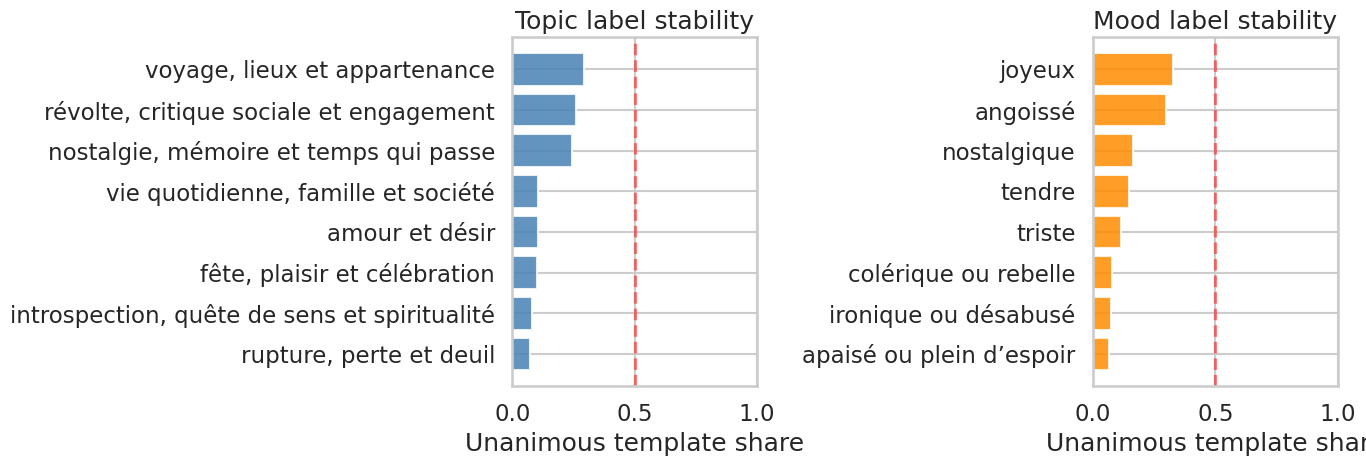

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tbl, name, c in [(axes[0], topic_label_stab, 'Topic', 'steelblue'),
                          (axes[1], mood_label_stab, 'Mood',  'darkorange')]:
    sub = tbl.dropna(subset=['all_agree_when_picked'])
    ax.barh(sub['label'], sub['all_agree_when_picked'], color=c, alpha=0.85)
    ax.set_xlim(0, 1); ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Unanimous template share')
    ax.set_title(f'{name} label stability')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'template_stability.png', dpi=200, bbox_inches='tight')
plt.show()

In [31]:
topic_label_stab.to_csv(OUTPUT_DIR / 'template_stability_by_label_topic.csv', index=False)
mood_label_stab.to_csv (OUTPUT_DIR / 'template_stability_by_label_mood.csv',  index=False)

Rephrasing the French hypothesis template changed the classifier's top-1 prediction on about two-thirds of the corpus. All-three-templates agreement sat at 35.6% for topics and 35.3% for moods, with pairwise κ ranging from 0.26 to 0.54 depending on the template pair.

The best-performing pair (tpl2 vs tpl3 for topic, κ = 0.54) shared similar syntax, the worst-performing pairs diverged more in sentence structure than in meaning.

At the label level, stability varied:
- Topic labels like voyage (29% unanimous) and révolte (26%) held up better than rupture (7%) and introspection (8%), which were highly sensitive to phrasing
- Mood labels like joyeux (33%) and angoissé (30%) were the most stable, apaisé ou plein d'espoir (7%), ironique ou désabusé (8%), and colérique ou rebelle (8%) were essentially unstable

These numbers confirm that zero-shot NLI predictions on fine-grained French labels carry real phrasing-dependent noise. Template variation should be treated as a source of measurement error, not a fixable bug. It comes from how NLI softmax distributes probability mass across semantically overlapping hypotheses.

## 8) Multi-Label Pass (derived from chunked scores)

Many songs carry more than one topic or one mood. A breakup song can be both `rupture, perte et deuil` and `introspection`; an angry love song can be both `colérique ou rebelle` and `amour et désir`. H: restricting the analysis to a single label per song throws away this information.

The multi-label pass uses the same score matrices as the top-1 pass but applies a threshold of 0.40: every label whose score clears the threshold is kept. If no label clears the threshold, the top-1 label is kept as a fallback so that every song receives at least one tag. The distribution of labels-per-song below is a useful diagnostic: a corpus where almost every song receives exactly one label suggests the threshold is too high, while a corpus where most songs receive four or more labels suggests it is too low

In [32]:
def multilabel_assignments(score_df, threshold=MULTI_LABEL_THRESHOLD):
    rows = []
    for _, r in score_df.iterrows():
        picks = [(lab, float(sc)) for lab, sc in r.items() if sc >= threshold]
        if not picks:
            top = r.idxmax(); picks = [(top, float(r[top]))]
        rows.append(sorted(picks, key=lambda x: -x[1]))
    return pd.Series(rows, index=score_df.index)


df['topic_multilabel'] = multilabel_assignments(topic_scores)
df['mood_multilabel']  = multilabel_assignments(mood_scores)

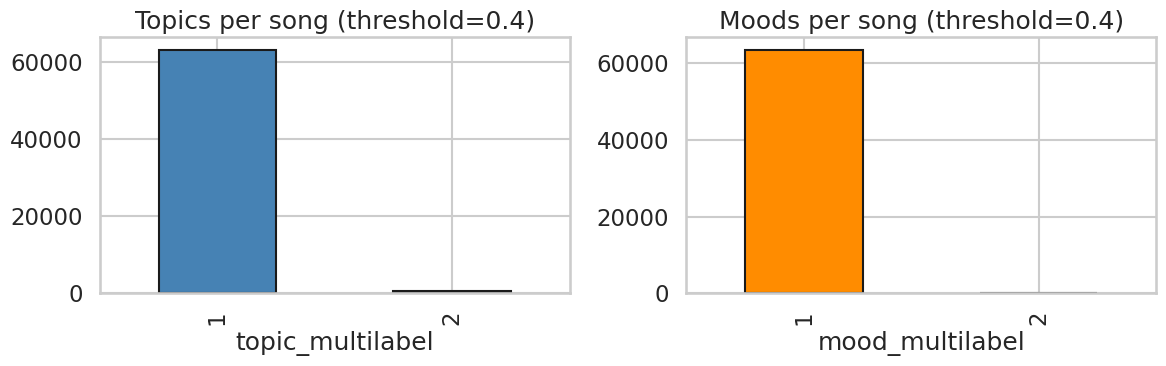

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['topic_multilabel'].str.len().value_counts().sort_index().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='k')
axes[0].set_title(f'Topics per song (threshold={MULTI_LABEL_THRESHOLD})')
df['mood_multilabel'].str.len().value_counts().sort_index().plot.bar(
    ax=axes[1], color='darkorange', edgecolor='k')
axes[1].set_title(f'Moods per song (threshold={MULTI_LABEL_THRESHOLD})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'multilabel_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## 9) Cross-model validation (M2: XLM-R-large)

Cross-model agreement is the closest thing to a validation signal that is available without human annotations. If two independently trained NLI models, fine-tuned on different data, produce similar predictions on the same corpus, that is meaningful evidence that the predictions are not just artefacts of one model's training.

The second model is `joeddav/xlm-roberta-large-xnli`, chosen because it is from a different model family than mDeBERTa and was fine-tuned on a different combination of NLI corpora.

Three metrics are computed:
- **Strict Cohen's κ on top-1 labels**

This is the strictest possible test: do the two models pick the same single best label for each song? With eight near-overlapping topic labels, top-1 κ can be punishingly low even when the models broadly agree, because a song that scores `amour` at 0.42 and `nostalgie` at 0.41 in M1 might flip in M2.
- **Spearman ρ on the full score vector for each song**

This asks a softer question: do the two models rank the eight labels in the same order, regardless of which one wins? A median ρ above 0.5 with a high share of songs above 0.5 indicates that the models broadly agree even when they tie-break differently.
- **Jaccard similarity on multi-label tag sets at threshold 0.30**

This matches how the labels are actually used downstream, as set-valued tags rather than single winners.

For mood, the Level-1 valence κ is also reported. A pattern where Level-0 κ is moderate but Level-1 κ is high is the expected and reassuring result: the models agree on whether a song is positive, negative, or ambivalent, even when they disagree on which fine-grained positive mood it carries.

In [ ]:
print(f'Loading {SECOND_MODEL}...')
zsc2 = pipeline('zero-shot-classification',
                model=SECOND_MODEL,
                device=DEVICE,
                torch_dtype=torch.float16)

In [35]:
# Decide what subset to run M2 on
if RUN_M2_FULL_CORPUS:
    df_cv = df
    cv_label = 'full'
    print(f'M2 will run on FULL corpus: {len(df_cv):,} songs')
else:
    df_cv = stratified_subsample(df, SECOND_MODEL_SUBSAMPLE)
    cv_label = 'cv'
    print(f'M2 will run on cross-val subsample: {len(df_cv):,} songs')

M2 will run on FULL corpus: 63,652 songs


In [36]:
print('Second-model topic classification:')
topic_scores_m2 = classify_chunked_cached(
    df_cv, text_col='lyrics_dedup',
    labels=TOPIC_LABELS_FR, template=TOPIC_TEMPLATE,
    classifier=zsc2, model_name=SECOND_MODEL,
    cache_name=f'm2_topic_{cv_label}', desc='m2-topic',
)

Second-model topic classification:
  [cache HIT  ] m2_topic_full                   (63,652 rows)


In [37]:
print('\nSecond-model mood classification:')
mood_scores_m2 = classify_chunked_cached(
    df_cv, text_col='lyrics_dedup',
    labels=MOOD_LABELS_FR, template=MOOD_TEMPLATE,
    classifier=zsc2, model_name=SECOND_MODEL,
    cache_name=f'm2_mood_{cv_label}',  desc='m2-mood',
)


Second-model mood classification:
  [cache HIT  ] m2_mood_full                    (63,652 rows)


In [38]:
del zsc2; torch.cuda.empty_cache()

In [39]:
# Strict κ + overall agreement on top-1
def cm_strict(m1_scores, m2_scores):
    m1_top = m1_scores.idxmax(axis=1).values
    m2_top = m2_scores.idxmax(axis=1).values
    return {
        'kappa' : float(cohen_kappa_score(m1_top, m2_top)),
        'agreement': float((m1_top == m2_top).mean()),
        'm1_top': m1_top, 'm2_top': m2_top,
    }


m1_topic_cv = topic_scores.loc[df_cv.index]
m1_mood_cv  = mood_scores.loc[df_cv.index]

strict_t = cm_strict(m1_topic_cv, topic_scores_m2)
strict_m = cm_strict(m1_mood_cv,  mood_scores_m2)

In [40]:
print(f'Strict κ (top-1), topic: {strict_t["kappa"]:.3f}, mood: {strict_m["kappa"]:.3f}')
print(f'Agreement (top-1),topic: {strict_t["agreement"]:.1%}, mood: {strict_m["agreement"]:.1%}')

Strict κ (top-1), topic: 0.283, mood: 0.162
Agreement (top-1),topic: 39.0%, mood: 34.2%


In [41]:
# Soft agreement: Spearman ρ on score vectors.
# Top-1 κ is brutal when labels tie-break. Spearman over the full score
# vector picks up the cases where the two models rank the labels in
# roughly the same order but disagree on which one wins.

def cm_soft_spearman(m1_scores, m2_scores):
    cols = list(m1_scores.columns)
    m1 = m1_scores[cols].values
    m2 = m2_scores[cols].values
    rhos = np.empty(len(m1), dtype=np.float32)
    for i in range(len(m1)):
        rho = spearmanr(m1[i], m2[i]).correlation
        rhos[i] = 0.0 if np.isnan(rho) else rho
    return rhos


soft_t = cm_soft_spearman(m1_topic_cv, topic_scores_m2)
soft_m = cm_soft_spearman(m1_mood_cv,  mood_scores_m2)

In [42]:
print(f'Soft Spearman ρ, topic: median={np.median(soft_t):.3f}, '
      f'mean={soft_t.mean():.3f}, share>0.5={(soft_t > 0.5).mean():.1%}')
print(f'Soft Spearman ρ, mood: median={np.median(soft_m):.3f}, '
      f'mean={soft_m.mean():.3f}, share>0.5={(soft_m > 0.5).mean():.1%}')

Soft Spearman ρ, topic: median=0.619, mean=0.569, share>0.5=64.3%
Soft Spearman ρ, mood: median=0.476, mean=0.460, share>0.5=47.3%


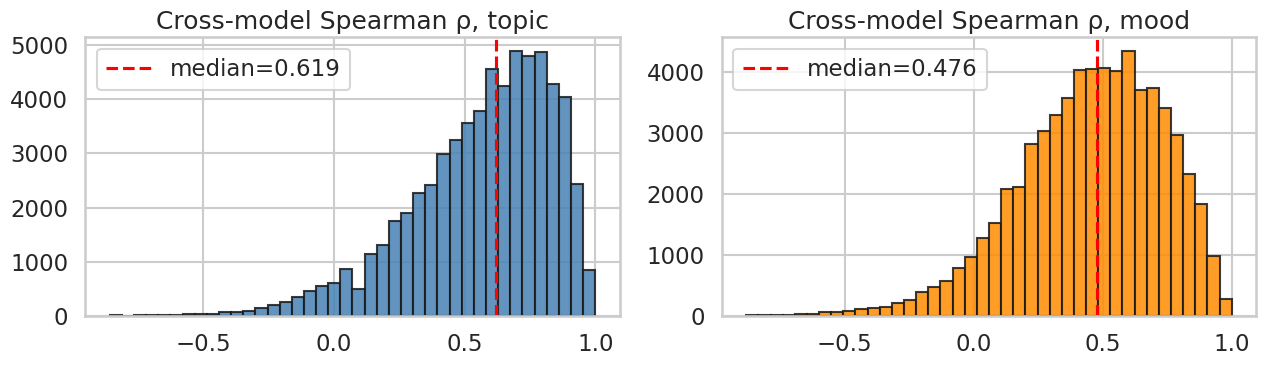

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(soft_t, bins=40, color='steelblue', edgecolor='k', alpha=0.85)
axes[0].axvline(np.median(soft_t), color='red', linestyle='--',
                label=f'median={np.median(soft_t):.3f}')
axes[0].set_title('Cross-model Spearman ρ, topic'); axes[0].legend()
axes[1].hist(soft_m, bins=40, color='darkorange', edgecolor='k', alpha=0.85)
axes[1].axvline(np.median(soft_m), color='red', linestyle='--',
                label=f'median={np.median(soft_m):.3f}')
axes[1].set_title('Cross-model Spearman ρ, mood'); axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'crossmodel_spearman.png', dpi=200, bbox_inches='tight')
plt.show()

In [44]:
# Multi-label Jaccard at threshold 0.3
def cm_jaccard(m1_scores, m2_scores, threshold=0.30):
    cols = list(m1_scores.columns)
    m1 = m1_scores[cols].values >= threshold
    m2 = m2_scores[cols].values >= threshold
    out = np.empty(len(m1), dtype=np.float32)
    for i in range(len(m1)):
        s1, s2 = set(np.where(m1[i])[0]), set(np.where(m2[i])[0])
        if not s1 and not s2:
            out[i] = 1.0
        elif not s1 or not s2:
            out[i] = 0.0
        else:
            out[i] = len(s1 & s2) / len(s1 | s2)
    return out


jacc_t = cm_jaccard(m1_topic_cv, topic_scores_m2)
jacc_m = cm_jaccard(m1_mood_cv,  mood_scores_m2)

In [45]:
print(f'Multi-label Jaccard (thr=0.30), topic: mean={jacc_t.mean():.3f}, '
      f'median={np.median(jacc_t):.3f}')
print(f'Multi-label Jaccard (thr=0.30), mood : mean={jacc_m.mean():.3f}, '
      f'median={np.median(jacc_m):.3f}')

Multi-label Jaccard (thr=0.30), topic: mean=0.396, median=0.000
Multi-label Jaccard (thr=0.30), mood : mean=0.332, median=0.000


In [46]:
# Level-1 valence κ (mood hierarchy)
def to_valence(top_labels):
    return np.array([MOOD_TO_VALENCE.get(l, 'autre') for l in top_labels])

val_m1 = to_valence(strict_m['m1_top'])
val_m2 = to_valence(strict_m['m2_top'])
val_kappa = cohen_kappa_score(val_m1, val_m2)
val_agree = (val_m1 == val_m2).mean()

In [47]:
print(f'Mood Level-1 (valence) κ: {val_kappa:.3f}')
print(f'Mood Level-1 (valence) agreement: {val_agree:.1%}')

Mood Level-1 (valence) κ: 0.307
Mood Level-1 (valence) agreement: 68.6%


In [48]:
# Per-label cross-model confirmation
def label_disagreement(m1_top, m2_top, labels, task):
    rows = []
    for lab in labels:
        mask = m1_top == lab
        if mask.sum() < 5: continue
        rows.append({'task': task, 'label': lab, 'n_m1': int(mask.sum()),
                     'm2_confirms': float((m2_top[mask] == lab).mean())})
    return pd.DataFrame(rows).sort_values('m2_confirms')


disag_topic = label_disagreement(strict_t['m1_top'], strict_t['m2_top'], TOPIC_LABELS_FR, 'topic')
disag_mood  = label_disagreement(strict_m['m1_top'], strict_m['m2_top'], MOOD_LABELS_FR,  'mood')
print('Per-label cross-model confirmation, topic'); display(disag_topic)
print('\nPer-label cross-model confirmation, mood'); display(disag_mood)

disag_topic.to_csv(OUTPUT_DIR / 'crossmodel_label_topic.csv', index=False)
disag_mood.to_csv (OUTPUT_DIR / 'crossmodel_label_mood.csv',  index=False)

Per-label cross-model confirmation, topic


,task,label,n_m1,m2_confirms
7,topic,"vie quotidienne, famille et société",684,0.061404
4,topic,"révolte, critique sociale et engagement",10416,0.155242
6,topic,"voyage, lieux et appartenance",17115,0.346889
5,topic,"introspection, quête de sens et spiritualité",606,0.369637
2,topic,"fête, plaisir et célébration",2328,0.399485
3,topic,"nostalgie, mémoire et temps qui passe",13973,0.447577
0,topic,amour et désir,16813,0.500803
1,topic,"rupture, perte et deuil",1717,0.798486



Per-label cross-model confirmation, mood


,task,label,n_m1,m2_confirms
5,mood,colérique ou rebelle,21177,0.014639
7,mood,ironique ou désabusé,1047,0.016237
4,mood,apaisé ou plein d’espoir,396,0.055556
3,mood,tendre,2260,0.419912
1,mood,triste,5209,0.452678
6,mood,angoissé,27064,0.524793
0,mood,joyeux,4513,0.539331
2,mood,nostalgique,1986,0.735146


In [49]:
# the cross-model summary
xm_summary = pd.DataFrame([
    {'task': 'topic', 'metric': 'strict_kappa_top1',     'value': strict_t['kappa']},
    {'task': 'topic', 'metric': 'top1_agreement_share',  'value': strict_t['agreement']},
    {'task': 'topic', 'metric': 'spearman_rho_median',   'value': float(np.median(soft_t))},
    {'task': 'topic', 'metric': 'spearman_rho_mean',     'value': float(soft_t.mean())},
    {'task': 'topic', 'metric': 'spearman_rho_share>0.5','value': float((soft_t > 0.5).mean())},
    {'task': 'topic', 'metric': 'jaccard_mean@0.30',     'value': float(jacc_t.mean())},
    {'task': 'mood',  'metric': 'strict_kappa_top1',     'value': strict_m['kappa']},
    {'task': 'mood',  'metric': 'top1_agreement_share',  'value': strict_m['agreement']},
    {'task': 'mood',  'metric': 'spearman_rho_median',   'value': float(np.median(soft_m))},
    {'task': 'mood',  'metric': 'spearman_rho_mean',     'value': float(soft_m.mean())},
    {'task': 'mood',  'metric': 'spearman_rho_share>0.5','value': float((soft_m > 0.5).mean())},
    {'task': 'mood',  'metric': 'jaccard_mean@0.30',     'value': float(jacc_m.mean())},
    {'task': 'mood',  'metric': 'valence_kappa_level1',  'value': val_kappa},
    {'task': 'mood',  'metric': 'valence_agreement_level1','value': val_agree},
])
xm_summary['value'] = xm_summary['value'].round(3)
print(xm_summary.to_string(index=False))
xm_summary.to_csv(OUTPUT_DIR / 'crossmodel_summary.csv', index=False)

 task                   metric  value
topic        strict_kappa_top1  0.283
topic     top1_agreement_share  0.390
topic      spearman_rho_median  0.619
topic        spearman_rho_mean  0.569
topic   spearman_rho_share>0.5  0.643
topic        jaccard_mean@0.30  0.396
 mood        strict_kappa_top1  0.162
 mood     top1_agreement_share  0.342
 mood      spearman_rho_median  0.476
 mood        spearman_rho_mean  0.460
 mood   spearman_rho_share>0.5  0.473
 mood        jaccard_mean@0.30  0.332
 mood     valence_kappa_level1  0.307
 mood valence_agreement_level1  0.686


Strict top-1 κ between mDeBERTa (M1) and XLM-R-large (M2) was 0.283 for topics and 0.162 for moods. On the surface, those numbers look poor. But most of the disagreement is in how the models break near-ties, not in how they rank the label set. Spearman ρ on the full 8-label score vector reached a median of 0.619 for topics (64% of songs above ρ = 0.5) and 0.476 for moods (47% above 0.5). The two models broadly agree about which labels fit and which don't; they disagree about which one wins when two or three labels are close.

At the valence level (positive / negative / ambivalent), mood agreement rose to κ = 0.307 and 68.6% raw agreement. That's consistent with the idea that both models read emotional polarity correctly but sort within-polarity categories differently.

Per-label confirmation separated the taxonomy into two tiers.
- Six topic labels cleared 35% cross-model confirmation: rupture (80%), amour (50%), nostalgie (45%), fête (40%), introspection (37%), and voyage (35%). Two did not: révolte (16%) and vie quotidienne (6%)

- For mood, five labels cleared 40%: nostalgique (74%), joyeux (54%), angoissé (52%), triste (45%), and tendre (42%). Three did not: colérique ou rebelle (1.5%), ironique ou désabusé (1.6%), and apaisé ou plein d'espoir (5.6%).

The three broken mood labels account for roughly 22,600 songs in M1's predictions. For `colérique ou rebelle` alone, M1 assigned it to 21,177 songs and M2 confirmed 310 of them. That label functions as a sink for negative-arousal content in mDeBERTa, XLM-R distributes those songs across angoissé, triste, and tendre instead. Any trend analysis on those labels would be measuring one model's idiosyncrasy, not a property of the lyrics

## 10) Ensemble predictor + confidence



The ensemble averages the M1 and M2 score matrices element-wise, then derives a top-1 label and confidence in the usual way. There is a useful property of this construction: when M1 and M2 disagree, the averaged top score is lower than either model's top score, so the AND-gate confidence policy is more likely to flag the song as `incertain`. Disagreement between the models gets converted into low confidence without any explicit disagreement-detection code.

The AND-gate fires when both conditions hold: the top score is below the absolute threshold (0.30) *and* the margin between the top two labels is below 0.06. Either condition alone is not enough to demote a prediction. A song with a top score of 0.28 but a comfortable margin over the runner-up is still a confident pick

If `RUN_M2_FULL_CORPUS=False`, the ensemble fields are populated only on the cross-validation subsample. For all other songs the final label falls back to the M1 prediction, and the column `ensemble_coverage` records which songs were and were not covered by the ensemble. The reported decade-level findings should be checked against `ensemble_coverage=True` when M2 is restricted to the subsample, to confirm that any temporal pattern is not driven by the M1-only fallback.

In [50]:
def ensemble_scores(s1, s2):
    cols = list(s1.columns)
    return pd.DataFrame((s1[cols].values + s2[cols].values) / 2,
                        index=s1.index, columns=cols)


# Ensemble on the cv slice
topic_ens_cv = ensemble_scores(m1_topic_cv, topic_scores_m2)
mood_ens_cv  = ensemble_scores(m1_mood_cv,  mood_scores_m2)

# Initialise full-corpus ensemble columns with M1 scores
topic_ens_full = topic_scores.copy()
mood_ens_full  = mood_scores.copy()
topic_ens_full.loc[topic_ens_cv.index, :] = topic_ens_cv.values
mood_ens_full.loc[mood_ens_cv.index,   :] = mood_ens_cv.values

df['topic_ens_label'], df['topic_ens_conf'], topic_ens_all = derive_topk(topic_ens_full)
df['mood_ens_label'],  df['mood_ens_conf'],  mood_ens_all  = derive_topk(mood_ens_full)
df['topic_ens_all_scores'] = topic_ens_all
df['mood_ens_all_scores']  = mood_ens_all

if not RUN_M2_FULL_CORPUS:
    df['ensemble_coverage'] = df.index.isin(df_cv.index)
    print(f'Ensemble coverage: {df["ensemble_coverage"].mean():.1%} '
          f'(M1 fallback for the rest)')
else:
    df['ensemble_coverage'] = True
    print('Ensemble coverage: 100% (full M2 corpus run)')

Ensemble coverage: 100% (full M2 corpus run)


In [51]:
def apply_confidence_policy(label, score, all_scores,
                            threshold=CONFIDENCE_THRESHOLD, margin=MARGIN_THRESHOLD):
    score_low  = score < threshold
    margin_low = (len(all_scores) >= 2) and ((score - all_scores[1][1]) < margin)
    return 'incertain' if (score_low and margin_low) else label

# Final labels: prefer ensemble where available, fall back to M1
df['topic_label_final'] = [
    apply_confidence_policy(lab, sc, al)
    for lab, sc, al in zip(df['topic_ens_label'], df['topic_ens_conf'], df['topic_ens_all_scores'])
]
df['mood_label_final'] = [
    apply_confidence_policy(lab, sc, al)
    for lab, sc, al in zip(df['mood_ens_label'], df['mood_ens_conf'], df['mood_ens_all_scores'])
]

print(f'Uncertain — topic: {(df["topic_label_final"] == "incertain").mean():.2%}')
print(f'Uncertain — mood : {(df["mood_label_final"]  == "incertain").mean():.2%}')

Uncertain — topic: 32.27%
Uncertain — mood : 47.48%


In [52]:
# Optional κ-floor filter
# Off by default, APPLY_KAPPA_FLOOR=True to enable.  When on,
# any label whose per-label cross-model confirmation rate falls below
# KAPPA_FLOOR is demoted to 'incertain'.  Most conservative reporting mode.

if APPLY_KAPPA_FLOOR:
    weak_topic = set(disag_topic[disag_topic['m2_confirms'] < KAPPA_FLOOR]['label'])
    weak_mood  = set(disag_mood [disag_mood ['m2_confirms'] < KAPPA_FLOOR]['label'])

    print(f'Demoting weak topic labels: {weak_topic}')
    print(f'Demoting weak mood labels : {weak_mood}')

    df.loc[df['topic_label_final'].isin(weak_topic), 'topic_label_final'] = 'incertain'
    df.loc[df['mood_label_final'].isin(weak_mood),   'mood_label_final']  = 'incertain'

    print(f'\nAfter κ-floor — topic incertain: {(df["topic_label_final"]=="incertain").mean():.2%}')
    print(f'After κ-floor — mood  incertain: {(df["mood_label_final"] =="incertain").mean():.2%}')
else:
    print('κ-floor filter is OFF')

κ-floor filter is OFF


Averaging M1 and M2 scores and applying the AND-gate (confidence ≥ 0.30, margin ≥ 0.06) flagged 32.3% of topic predictions and 47.5% of mood predictions as incertain. The mood rate is high but honest: it absorbs exactly the songs where the two models disagree, which are disproportionately the broken labels. The ensemble is doing what it was designed to do: translate model disagreement into explicit uncertainty rather than hiding it behind a single model's confident-but-wrong top-1.

## 11) Gold standard subset

The cross-model agreement metrics in section 9 are evidence of consistency, not of correctness. Two models that share the same blind spot will agree without being right. The only way to estimate the absolute accuracy of the pipeline is to compare its predictions to human judgement on a sample.

The gold subset exported here is stratified by decade and final topic label, w/ at least one song per (decade, label) cell where possible. Each row carries the song title, artist, decade, the ensemble's predicted topic and mood, and a snippet of the cleaned lyrics. The columns `topic_human` and `mood_human` are left blank for the annotator to fill in

When the annotated file is returned and dropped back into the output directory, the loader in the next cell reads it and computes a classification report and macro-F1 against the human labels for both topic and mood. Until then, this section produces only the export.

In [53]:
def export_gold_sample(frame, n=GOLD_SAMPLE_SIZE, seed=SEED, snippet_chars=600):
    rng = np.random.default_rng(seed)
    strata = frame.groupby(['decade', 'topic_label_final'])
    per = max(1, n // strata.ngroups)
    parts = []
    for _, g in strata:
        if len(g) == 0: continue
        parts.append(g.sample(min(per, len(g)), random_state=seed))
    sample = pd.concat(parts).reset_index(drop=True)
    if len(sample) > n:
        sample = sample.sample(n, random_state=seed).reset_index(drop=True)
    return pd.DataFrame({
        'gold_id'   : range(1, len(sample) + 1),
        'song_title': sample['song_title'],
        'artist_name': sample['artist_name'],
        'year'      : sample['year'],
        'decade'    : sample['decade'],
        'lyrics_snippet': sample['lyrics_dedup'].str.slice(0, snippet_chars),
        'topic_human': '', 'topic_human_secondary': '',
        'mood_human' : '', 'mood_human_secondary' : '',
        'notes'     : '',
        '_predicted_topic'      : sample['topic_label_final'],
        '_predicted_topic_conf' : sample['topic_ens_conf'].round(3),
        '_predicted_mood'       : sample['mood_label_final'],
        '_predicted_mood_conf'  : sample['mood_ens_conf'].round(3),
    })


gold_template = export_gold_sample(df)
print(f'Gold sample: {len(gold_template)} songs')

clean = gold_template.drop(columns=[c for c in gold_template.columns if c.startswith('_')])
clean.to_csv(OUTPUT_DIR / 'gold_template_annotator_blank.csv', index=False)
gold_template.to_csv(OUTPUT_DIR / 'gold_template_analyst_reference.csv', index=False)

Gold sample: 182 songs


In [56]:
from sklearn.metrics import classification_report, f1_score


def load_gold(path):
    if not path.exists():
        print(f'[skip] {path.name} not found')
        return None
    g = pd.read_csv(path)
    g['topic_human'] = g['topic_human'].astype(str).str.strip()
    g['mood_human']  = g['mood_human'].astype(str).str.strip()
    return g


a1 = load_gold(OUTPUT_DIR / 'gold_annotator_1.csv')
a2 = load_gold(OUTPUT_DIR / 'gold_annotator_2.csv')

if a1 is not None and a2 is not None:
    merged = (gold_template[['gold_id','_predicted_topic','_predicted_mood']]
              .merge(a1[['gold_id','topic_human','mood_human']]
                       .rename(columns={'topic_human':'topic_a1','mood_human':'mood_a1'}),
                     on='gold_id')
              .merge(a2[['gold_id','topic_human','mood_human']]
                       .rename(columns={'topic_human':'topic_a2','mood_human':'mood_a2'}),
                     on='gold_id'))

    t = merged.query('topic_a1 != "" and topic_a2 != ""').copy()
    m = merged.query('mood_a1  != "" and mood_a2  != ""' ).copy()
    t['topic_consensus'] = np.where(t['topic_a1'] == t['topic_a2'], t['topic_a1'], '__disagree__')
    m['mood_consensus']  = np.where(m['mood_a1']  == m['mood_a2'],  m['mood_a1'],  '__disagree__')

    ct = t[t['topic_consensus'] != '__disagree__']
    cm = m[m['mood_consensus']  != '__disagree__']
    print(f'Classifier vs consensus (n_topic={len(ct)}, n_mood={len(cm)})')
    print(f'Topic κ : {cohen_kappa_score(ct["_predicted_topic"], ct["topic_consensus"]):.3f}')
    print(f'Topic F1: {f1_score(ct["topic_consensus"], ct["_predicted_topic"], average="macro"):.3f}')
    print(f'Mood  κ : {cohen_kappa_score(cm["_predicted_mood"],  cm["mood_consensus"]):.3f}')
    print(f'Mood  F1: {f1_score(cm["mood_consensus"],  cm["_predicted_mood"], average="macro"):.3f}')
    print('\nTopic per-label'); print(classification_report(
        ct['topic_consensus'], ct['_predicted_topic'], zero_division=0))
    print('\nMood per-label');  print(classification_report(
        cm['mood_consensus'],  cm['_predicted_mood'],  zero_division=0))

    t.to_csv(OUTPUT_DIR / 'gold_results_topic.csv', index=False)
    m.to_csv(OUTPUT_DIR / 'gold_results_mood.csv',  index=False)
else:
    print('Fill gold_annotator_1.csv and gold_annotator_2.csv')

Classifier vs consensus (n_topic=182, n_mood=182)
Topic κ : 0.360
Topic F1: 0.397
Mood  κ : 0.178
Mood  F1: 0.203

Topic per-label
                                              precision    recall  f1-score   support

                              amour et désir       0.64      0.40      0.49        35
                fête, plaisir et célébration       0.45      0.53      0.49        17
                                   incertain       0.00      0.00      0.00         0
introspection, quête de sens et spiritualité       0.41      0.29      0.34        24
       nostalgie, mémoire et temps qui passe       0.27      0.46      0.34        13
                     rupture, perte et deuil       0.41      0.53      0.46        17
     révolte, critique sociale et engagement       0.71      0.42      0.53        36
         vie quotidienne, famille et société       0.86      0.38      0.52        32
               voyage, lieux et appartenance       0.27      0.75      0.40         8

       

! Warning: the sample is small and should only be deemed as additional guidance :)

Against a single-annotator gold standard (n = 182 stratified songs), the ensemble achieved topic κ = 0.36 and macro-F1 = 0.40; mood κ = 0.18 and macro-F1 = 0.20.

Topic accuracy (43%) was spread unevenly across labels. The classifier achieved high precision on révolte (71%), vie quotidienne (86%), and amour (64%) — when it picked those labels, it was usually right. But recall was low for the same categories (38–42%), meaning it missed many songs the annotator coded that way. Voyage showed the opposite pattern: low precision (27%) but high recall (75%), making it a catch-all that the classifier over-assigns.

Mood accuracy (24%) was pulled down by three categories the classifier didnt predict correctly: ironique ou désabusé (F1 = 0.00 against 29 gold songs), apaisé ou plein d'espoir (F1 = 0.00 against 9 songs), and colérique ou rebelle (F1 = 0.22). These are the same three labels that failed the cross-model check in §9 and the template stability check in §7. Three independent diagnostics: template sensitivity, cross-model agreement, and gold-standard validation -- all converge on the same broken labels.

## 12) Calibration (Reliability diagram + ECE)

Gold loaded: 182 songs


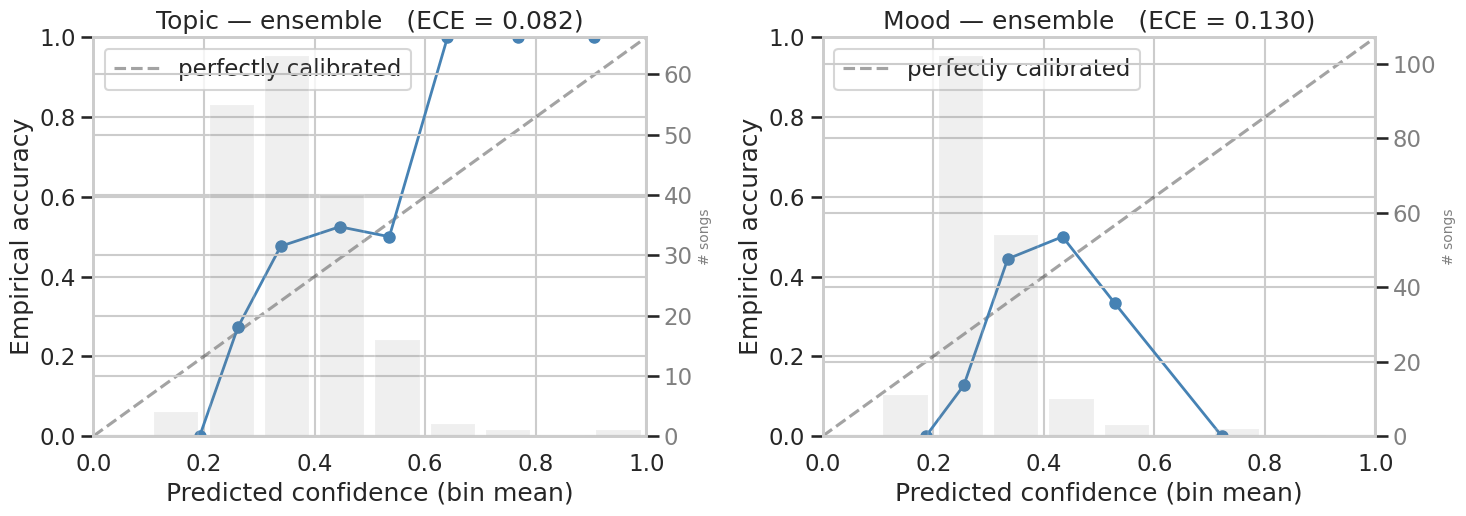

Topic ECE: 0.082
Mood  ECE: 0.130

Mood κ  (5 reliable labels, n=63): 0.516
Mood F1 (5 reliable labels, n=63): 0.612


In [60]:
from sklearn.metrics import cohen_kappa_score, f1_score

# Load gold
ref = pd.read_csv(OUTPUT_DIR / 'gold_template_analyst_reference.csv')
ann = pd.read_csv(OUTPUT_DIR / 'gold_annotator_1.csv')
ann['topic_human'] = ann['topic_human'].astype(str).str.strip()
ann['mood_human']  = ann['mood_human'].astype(str).str.strip()

# Merge only the columns we need from each file
gold = ref[['gold_id', '_predicted_topic', '_predicted_topic_conf',
            '_predicted_mood', '_predicted_mood_conf']].merge(
    ann[['gold_id', 'topic_human', 'mood_human']], on='gold_id')

gold = gold[gold['topic_human'].notna() & (gold['topic_human'] != '')]
print(f'Gold loaded: {len(gold)} songs')

# Reliability diagram function
def reliability_diagram(scores, correct, n_bins=10, title='', ax=None):
    bins = np.linspace(0, 1, n_bins + 1)
    digit = np.digitize(scores, bins[1:-1])
    rows, ece = [], 0.0
    n = len(scores)
    for b in range(n_bins):
        mask = digit == b
        if mask.sum() == 0:
            rows.append({'bin_mid': (bins[b]+bins[b+1])/2, 'n': 0,
                         'mean_conf': np.nan, 'accuracy': np.nan})
            continue
        mc = float(scores[mask].mean())
        ac = float(correct[mask].mean())
        ece += (mask.sum() / n) * abs(mc - ac)
        rows.append({'bin_mid': (bins[b]+bins[b+1])/2,
                     'n': int(mask.sum()),
                     'mean_conf': mc, 'accuracy': ac})
    out = pd.DataFrame(rows)
    if ax is not None:
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='perfectly calibrated')
        keep = out.dropna()
        ax.plot(keep['mean_conf'], keep['accuracy'], 'o-',
                linewidth=2, markersize=8, color='steelblue')
        # Density bars
        ax2 = ax.twinx()
        ax2.bar(out['bin_mid'], out['n'], width=0.08, alpha=0.12, color='gray')
        ax2.set_ylabel('# songs', color='gray', fontsize=10)
        ax2.tick_params(axis='y', labelcolor='gray')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel('Predicted confidence (bin mean)')
        ax.set_ylabel('Empirical accuracy')
        ax.set_title(f'{title}   (ECE = {ece:.3f})')
        ax.legend(loc='upper left')
    return out, ece

# Build aligned arrays: predicted label, confidence, human label
topic_correct = (gold['_predicted_topic'] == gold['topic_human']).values.astype(int)
topic_conf    = gold['_predicted_topic_conf'].values.astype(float)

mood_correct  = (gold['_predicted_mood'] == gold['mood_human']).values.astype(int)
mood_conf     = gold['_predicted_mood_conf'].values.astype(float)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
t_bins, t_ece = reliability_diagram(topic_conf, topic_correct,
                                     title='Topic — ensemble', ax=axes[0])
m_bins, m_ece = reliability_diagram(mood_conf, mood_correct,
                                     title='Mood — ensemble', ax=axes[1])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'reliability_diagram.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Topic ECE: {t_ece:.3f}')
print(f'Mood  ECE: {m_ece:.3f}')

t_bins.to_csv(OUTPUT_DIR / 'reliability_bins_topic.csv', index=False)
m_bins.to_csv(OUTPUT_DIR / 'reliability_bins_mood.csv',  index=False)

# Bonus: restricted mood κ/F1 on the 5 reliable labels
reliable_moods = {'angoissé', 'joyeux', 'nostalgique', 'tendre', 'triste'}
mask_r = (gold['mood_human'].isin(reliable_moods) &
          gold['_predicted_mood'].isin(reliable_moods))
n_r = mask_r.sum()

if n_r > 20:
    k_r  = cohen_kappa_score(gold.loc[mask_r, 'mood_human'],
                              gold.loc[mask_r, '_predicted_mood'])
    f1_r = f1_score(gold.loc[mask_r, 'mood_human'],
                     gold.loc[mask_r, '_predicted_mood'], average='macro')
    print(f'\nMood κ  (5 reliable labels, n={n_r}): {k_r:.3f}')
    print(f'Mood F1 (5 reliable labels, n={n_r}): {f1_r:.3f}')
else:
    print(f'\nOnly {n_r} songs in reliable-mood subset, too few to compute κ')

For topic classification, the ensemble's predicted confidence tracks actual accuracy closely (ECE = 0.082). A model that reports 0.40 confidence gets the label right about 40% of the time, which means the AND-gate threshold of 0.30 is a reasonable cutoff, not an arbitrary one. Mood calibration is less tight (ECE = 0.130). The reliability curve peaks around 0.40 and then drops — the model becomes overconfident at higher scores, largely because the three broken labels from §9 pull accuracy down even when predicted confidence is high. Restricting the mood evaluation to the five cross-model-validated labels (angoissé, joyeux, nostalgique, tendre, triste) brings agreement against the gold standard up to κ = 0.52 and macro-F1 = 0.61 (n = 63), which puts the classifier in the moderate-to-good range for a 5-class emotion task.

## 13) Genre confound analysis

If certain topics are unevenly distributed across genres, and if genre composition shifts over time, then any apparent diachronic trend in topic shares might be a genre-mix artefact rather than a genuine shift in lyrical content. The most plausible example is the rise of rap from the 1990s onward: if rap is over-represented in `révolte, critique sociale et engagement`, then the apparent growth of that topic from the 1990s onward partly reflects the changing share of rap in the corpus rather than a topical shift internal to French song as a whole.

This section addresses the confound in two ways. A stacked bar chart shows the genre composition of each decade so that the magnitude of the genre-mix shift is visible. A multinomial logistic regression with decade (centred and continuous) and genre as predictors then estimates the decade effect *holding genre constant*. If the decade coefficients survive the addition of genre fixed effects, the temporal pattern is robust to the confound; if they collapse, the pattern is largely a genre-mix story.



In [ ]:
GENRE_COL = 'tag' if 'tag' in df.columns else ('genre' if 'genre' in df.columns else None)
if GENRE_COL is None:
    raise RuntimeError('No genre column found.')

TOP_K_GENRES = 6
top_genres = df[GENRE_COL].value_counts().head(TOP_K_GENRES).index.tolist()
df['genre_top'] = df[GENRE_COL].where(df[GENRE_COL].isin(top_genres), 'other')
print(f'Top genres: {top_genres}')

Top genres: ['rap', 'pop', 'rock', 'rb', 'misc', 'country']


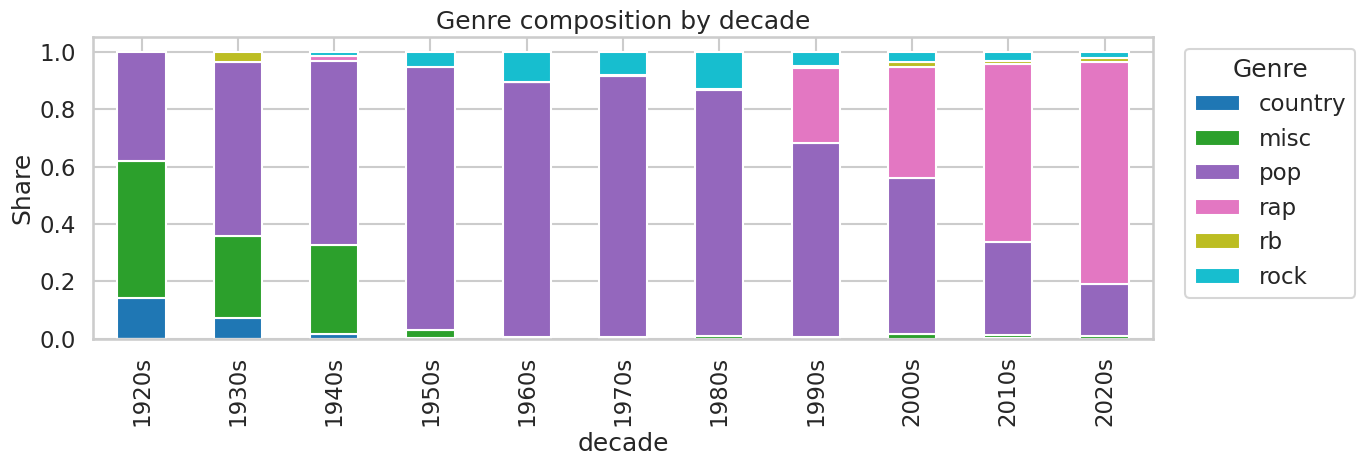

In [ ]:
ord_decs = sort_decades(df['decade'].unique())
gen_pivot = df.groupby(['decade','genre_top']).size().unstack(fill_value=0).loc[ord_decs]
gen_share = gen_pivot.div(gen_pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
gen_share.plot(kind='bar', stacked=True, colormap='tab10', ax=ax)
ax.set_title('Genre composition by decade'); ax.set_ylabel('Share')
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'genre_composition_by_decade.png', dpi=200, bbox_inches='tight')
plt.show()
gen_share.to_csv(OUTPUT_DIR / 'genre_composition_by_decade.csv')

In [ ]:
import statsmodels.formula.api as smf

work = df[df['topic_label_final'] != 'incertain'].copy()
work['decade_idx'] = work['decade'].str.extract(r'(\d{4})').astype(int) // 10
work['decade_c']   = work['decade_idx'] - work['decade_idx'].mean()
work['genre_top']  = work['genre_top'].astype('category')

rows = []
for lab in TOPIC_LABELS_FR:
    work['y'] = (work['topic_label_final'] == lab).astype(int)
    if work['y'].sum() < 30: continue
    try:
        u = smf.logit('y ~ decade_c', data=work).fit(disp=False, maxiter=200)
        a = smf.logit('y ~ decade_c + C(genre_top)', data=work).fit(disp=False, maxiter=200)
        bu, pu = u.params['decade_c'], u.pvalues['decade_c']
        ba, pa = a.params['decade_c'], a.pvalues['decade_c']
        rows.append({'topic': lab,
                     'beta_unadj': round(float(bu), 3), 'p_unadj': float(pu),
                     'beta_adj'  : round(float(ba), 3), 'p_adj'  : float(pa),
                     'attenuation': round(float(bu - ba), 3),
                     'attenuation_pct': round(100*(bu - ba)/bu, 1) if abs(bu) > 1e-6 else np.nan})
    except Exception as exc:
        rows.append({'topic': lab, 'error': str(exc)[:60]})

confound_df = pd.DataFrame(rows).sort_values('attenuation_pct',
                                              key=lambda s: s.abs(), ascending=False)
print('=== Decade effect: unadjusted vs genre-adjusted ===')
display(confound_df)
confound_df.to_csv(OUTPUT_DIR / 'genre_confound_decomposition.csv', index=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


=== Decade effect: unadjusted vs genre-adjusted ===


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


,topic,beta_unadj,p_unadj,beta_adj,p_adj,attenuation,attenuation_pct,error
4,"révolte, critique sociale et engagement",0.088,1.323164e-13,-0.187,1.096533e-42,0.275,313.3,NaN
0,amour et désir,-0.139,6.598077e-98,-0.041,1.568291e-08,-0.098,70.5,NaN
2,"fête, plaisir et célébration",-0.125,8.736037e-17,-0.042,1.134579e-02,-0.083,66.4,NaN
1,"rupture, perte et deuil",0.097,1.423008e-16,0.033,1.057367e-02,0.065,66.3,NaN
6,"voyage, lieux et appartenance",0.054,6.568820e-13,0.030,2.354216e-04,0.024,44.2,NaN
3,"nostalgie, mémoire et temps qui passe",0.060,1.679499e-15,0.075,1.238897e-19,-0.015,-24.4,NaN
5,"introspection, quête de sens et spiritualité",NaN,NaN,NaN,NaN,NaN,NaN,Singular matrix
7,"vie quotidienne, famille et société",NaN,NaN,NaN,NaN,NaN,NaN,Singular matrix


The corpus composition shifted substantially across decades: rap went from absent in the 1920s–1970s to dominant from the 2000s onward, while pop and rock share declined. Any "decade trend" that tracks genre composition rather than within-genre change is a confound, not a cultural finding.

Logistic regression decomposition exposed this clearly for révolte, critique sociale et engagement. The unadjusted decade coefficient was positive (+0.088, p < 10⁻¹³) — révolte appeared to rise across the century. After controlling for genre, the coefficient reversed to negative (−0.187, p < 10⁻⁴²). The entire apparent rise in protest themes, and then some, is explained by the growing share of rap in the corpus. Within any single genre, révolte actually declined.
For amour et désir, the unadjusted coefficient was −0.139 (declining). Genre-adjustment reduced it to −0.041 — still negative and significant, but 70% smaller. The decline in love songs is partly real and partly a genre-mix effect. Similar attenuation applied to fête (66%) and rupture (66%).

Nostalgie, mémoire et temps qui passe went the other direction: the unadjusted decade coefficient was +0.060, and the adjusted coefficient was +0.075. Nostalgia's rise across the century actually strengthened once genre was controlled for. This makes it the most robust topic trend in the analysis — it holds across genres and gets slightly more pronounced when compositional effects are removed.
Two labels (introspection, vie quotidienne) produced singular matrix errors in the logistic regression, meaning their data was too sparse or too perfectly separated to estimate a genre-adjusted coefficient. Trend claims on those labels should be treated with extra caution.

## 14) Aggregate topics and moods by decade

This section produces the headline visualisations: per-decade shares of each topic label and each mood label, plotted as both stacked area charts (to show composition) and small-multiples line charts (to show individual trajectories). The plotting function is reused for the multi-label tags and for the valence-level mood aggregation, so each label set is shown at three granularitiesю

/tmp/ipykernel_658/3824403298.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), cap), random_state=seed))
/tmp/ipykernel_658/3824403298.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), cap), random_state=seed))
/tmp/ipykernel_658/2104597942.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made 

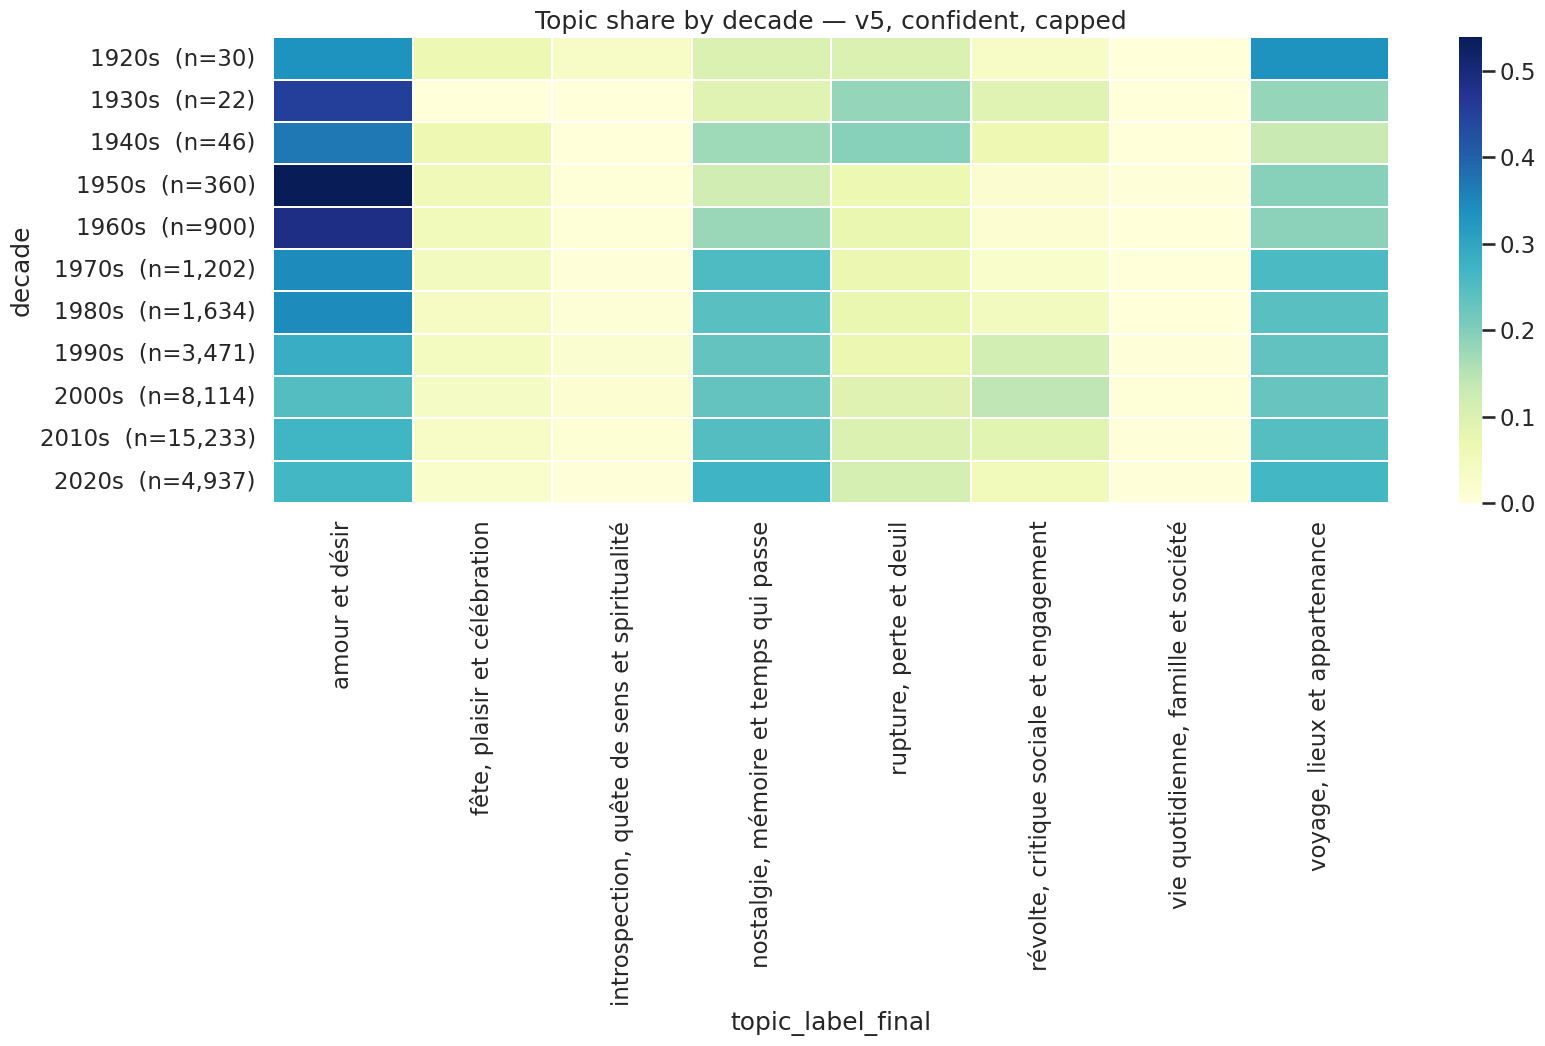

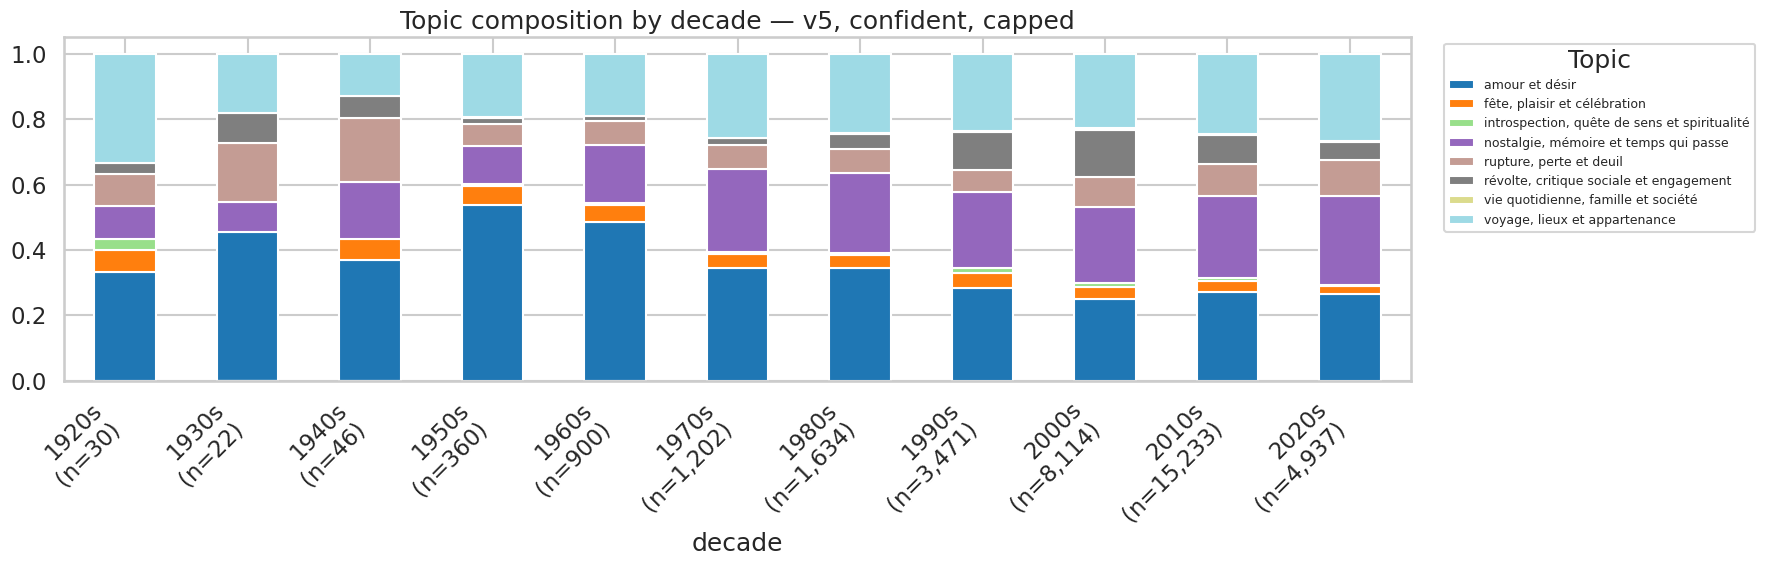

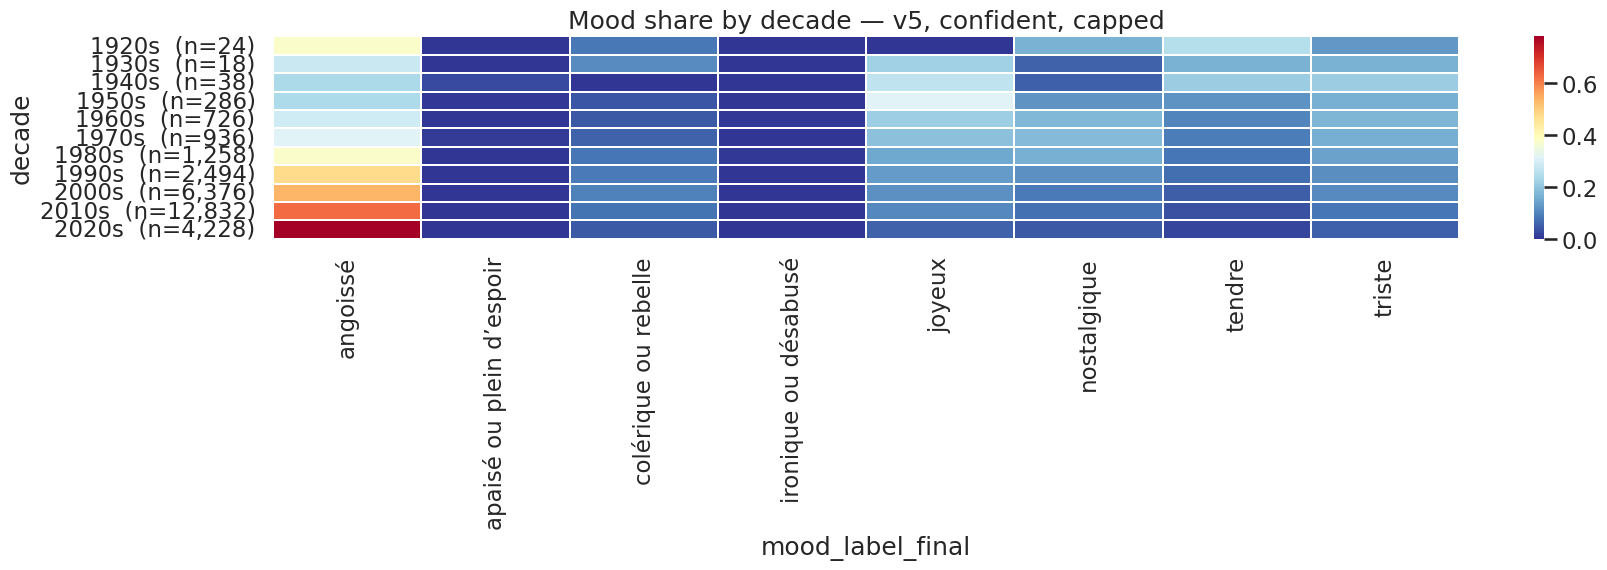

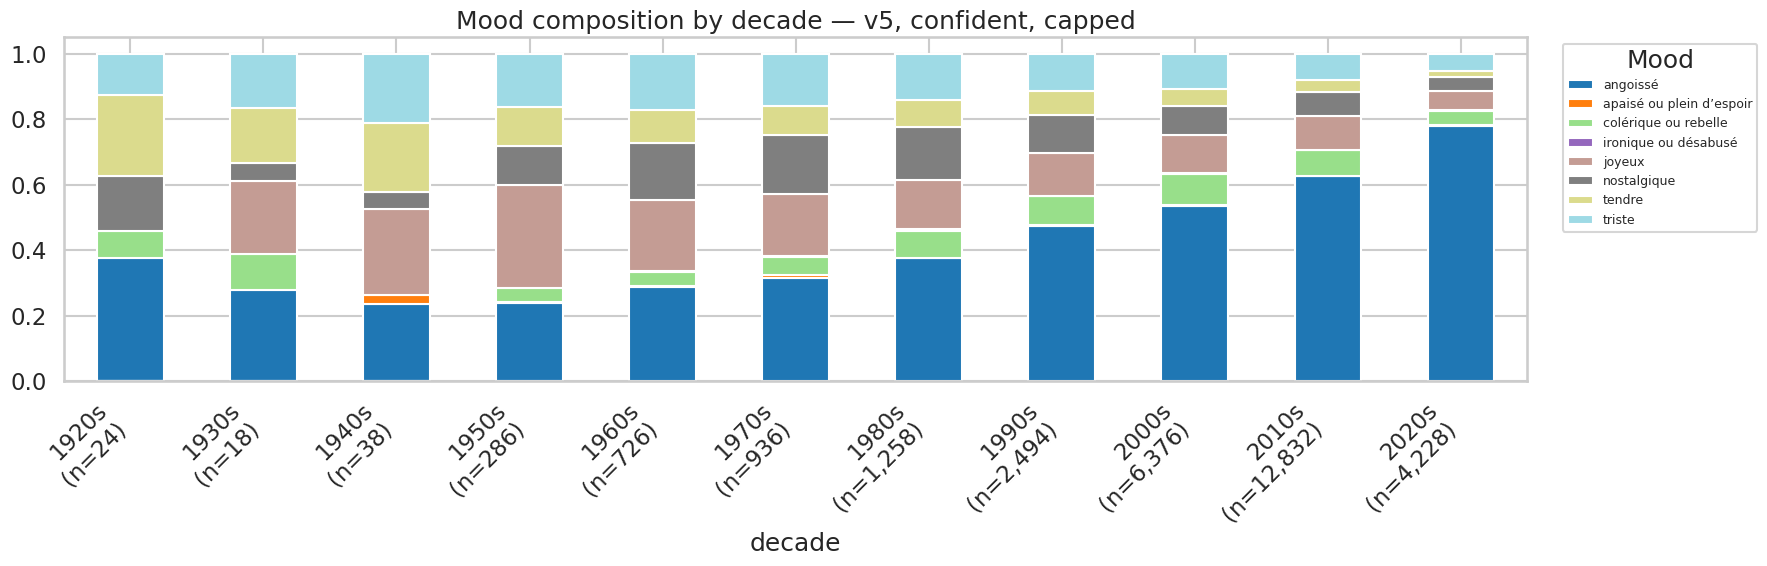

In [ ]:
def plot_topic_or_mood(df_input, label_col, name, suffix='', title_suffix='', cmap='YlGnBu'):
    counts = df_input.groupby(['decade', label_col]).size().rename('n').reset_index()
    counts['share'] = counts.groupby('decade')['n'].transform(lambda s: s/s.sum())
    pivot = counts.pivot(index='decade', columns=label_col, values='share').fillna(0)
    pivot = pivot.loc[[d for d in sort_decades(counts['decade'].unique()) if d in pivot.index]]
    dec_n = counts.groupby('decade')['n'].sum()

    fig, ax = plt.subplots(figsize=(18, max(4, len(pivot) * 0.55)))
    sns.heatmap(pivot, cmap=cmap, linewidths=0.2, ax=ax,
                yticklabels=[f'{d}  (n={dec_n[d]:,})' for d in pivot.index], vmin=0)
    ax.set_title(f'{name} share by decade{title_suffix}')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{name.lower()}_heatmap{suffix}.png', dpi=200, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(18, 6))
    pivot.plot(kind='bar', stacked=True, colormap='tab20', ax=ax)
    ax.set_xticklabels([f'{d}\n(n={dec_n[d]:,})' for d in pivot.index], rotation=45, ha='right')
    ax.set_title(f'{name} composition by decade{title_suffix}')
    ax.legend(title=name, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{name.lower()}_stacked_bar{suffix}.png', dpi=200, bbox_inches='tight')
    plt.show()
    return counts, pivot


df_certain_topic = df[df['topic_label_final'] != 'incertain'].copy()
df_certain_mood  = df[df['mood_label_final']  != 'incertain'].copy()
df_ct_capped = apply_artist_cap(df_certain_topic, ARTIST_DECADE_CAP)
df_cm_capped = apply_artist_cap(df_certain_mood,  ARTIST_DECADE_CAP)

topic_counts_c, topic_pivot_c = plot_topic_or_mood(
    df_ct_capped, 'topic_label_final', 'Topic',
    '_v5_capped', ' — v5, confident, capped', 'YlGnBu')
mood_counts_c, mood_pivot_c = plot_topic_or_mood(
    df_cm_capped, 'mood_label_final', 'Mood',
    '_v5_capped', ' — v5, confident, capped', 'RdYlBu_r')

## 15) Cluster bootstrap on artists

Per-decade label shares would normally be reported with binomial confidence intervals, but that is the wrong uncertainty model here. Songs by the same artist are not independent observations. An artist who writes ten breakup songs in a decade contributes ten correlated data points, not ten independent ones, and a naive binomial interval understates the true uncertainty.

The cluster bootstrap addresses this by resampling artists (not songs) with replacement within each decade, recomputing the label shares on each bootstrap sample, and reporting the 2.5th and 97.5th percentiles as the confidence interval. With 1000 bootstrap iterations the intervals are stable enough to report in the thesis. The resulting intervals are noticeably wider than the binomial equivalent, which is the honest reflection of the artist-clustering in the corpus.

In [ ]:
def cluster_bootstrap(frame, label_col, n_boot=N_BOOT_CLUSTER, alpha=0.05, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    decs = sort_decades(frame['decade'].dropna().unique())
    labels = sorted(frame[label_col].dropna().unique())
    rows = []
    for dec in tqdm(decs, desc=f'Cluster boot {label_col}'):
        sub = frame[frame['decade'] == dec]
        artists = sub['artist_name'].unique()
        if len(artists) < 5 or len(sub) < 20: continue
        a_idx = {a: np.where(sub['artist_name'].values == a)[0] for a in artists}
        lab_arr = sub[label_col].values
        a_counts = np.zeros((len(artists), len(labels)), dtype=np.float32)
        for ai, a in enumerate(artists):
            arr = lab_arr[a_idx[a]]
            for li, lab in enumerate(labels):
                a_counts[ai, li] = (arr == lab).sum()
        a_sizes = a_counts.sum(axis=1)
        draws = np.zeros((n_boot, len(labels)), dtype=np.float32)
        for b in range(n_boot):
            sampled = rng.integers(0, len(artists), size=len(artists))
            draws[b] = a_counts[sampled].sum(axis=0) / max(a_sizes[sampled].sum(), 1)
        for li, lab in enumerate(labels):
            col = draws[:, li]
            rows.append({'decade': dec, 'label': lab,
                         'mean_share': float(col.mean()),
                         'ci_low':     float(np.quantile(col, alpha/2)),
                         'ci_high':    float(np.quantile(col, 1-alpha/2)),
                         'n_artists':  int(len(artists)), 'n_songs': int(len(sub)),
                         'label_type': label_col, 'boot_type': 'cluster_artist'})
    out = pd.DataFrame(rows)
    out['ci_width'] = out['ci_high'] - out['ci_low']
    return out


topic_ci_cluster = cluster_bootstrap(df_ct_capped, 'topic_label_final')
mood_ci_cluster  = cluster_bootstrap(df_cm_capped, 'mood_label_final')
topic_ci_cluster.to_csv(OUTPUT_DIR / 'topic_ci_cluster_capped.csv', index=False)
mood_ci_cluster.to_csv (OUTPUT_DIR / 'mood_ci_cluster_capped.csv',  index=False)

## 16. Trend tests: Mann-Kendall and Sen's slope

Plotting per-decade shares and squinting at the line chart is not a defensible way to claim that a topic is rising or falling over time. This section runs two non-parametric trend tests on the per-decade share series for every label.

The Mann-Kendall test reports whether there is a monotone trend (rising or falling) without assuming linearity or normality. Sen's slope gives a robust estimate of the magnitude of the trend in percentage points per decade. Both are appropriate for short time series with potential outliers, which is what per-decade label shares are.

Because the tests are run independently on every label, the p-values are corrected for multiple comparisons using the Benjamini-Hochberg false discovery rate procedure. The forest plot at the end of the section shows the corrected slopes side by side, sorted from most negative to most positive, with significance markers. This is the single visualisation that most directly answers the question of which topics and moods are gaining or losing ground over the period covered by the corpus.

In [ ]:
import pymannkendall as mk
from statsmodels.stats.multitest import multipletests


def mk_sen_table(pivot, series_type):
    rows = []
    for col in pivot.columns:
        s = pivot[col].values
        if len(s) < 4: continue
        r = mk.original_test(s)
        rows.append({
            'series_type': series_type, 'series_id': col, 'n_decades': len(s),
            'trend': r.trend, 'S': float(r.s), 'Z': float(r.z),
            'p_value': float(r.p), 'tau': float(r.Tau),
            'sens_slope': float(r.slope),
            'sens_slope_pp_per_decade': float(r.slope * 100),
            'sens_intercept': float(r.intercept),
        })
    return pd.DataFrame(rows)


mk_all = pd.concat([mk_sen_table(topic_pivot_c, 'topic'),
                    mk_sen_table(mood_pivot_c,  'mood')], ignore_index=True)
_, q, _, _ = multipletests(mk_all['p_value'].values, method='fdr_bh')
mk_all['fdr_bh'] = q
mk_all['sig'] = mk_all['fdr_bh'].apply(
    lambda q: '***' if q<0.01 else ('**' if q<0.05 else ('*' if q<0.10 else '')))
mk_all = mk_all.sort_values(['series_type','fdr_bh']).reset_index(drop=True)
display(mk_all)
mk_all.to_csv(OUTPUT_DIR / 'mk_sens_slope_trends.csv', index=False)
print(f'\nSignificant trends (FDR q<0.10): {(mk_all["fdr_bh"] < 0.10).sum()} / {len(mk_all)}')

,series_type,series_id,n_decades,trend,S,Z,p_value,tau,sens_slope,sens_slope_pp_per_decade,sens_intercept,fdr_bh,sig
0,mood,tendre,11,decreasing,-53.0,-4.048195,0.000052,-0.963636,-0.016418,-1.641756,0.170763,0.000826,***
1,mood,angoissé,11,increasing,41.0,3.113996,0.001846,0.745455,0.049663,4.966266,0.126687,0.014766,**
2,mood,triste,11,decreasing,-37.0,-2.802596,0.005069,-0.672727,-0.015738,-1.573839,0.219391,0.020277,**
3,mood,joyeux,11,decreasing,-29.0,-2.179797,0.029273,-0.527273,-0.022230,-2.223019,0.261389,0.058545,*
4,mood,nostalgique,11,no trend,-15.0,-1.089899,0.275758,-0.272727,-0.007256,-0.725551,0.152156,0.441213,
5,mood,ironique ou désabusé,11,no trend,13.0,0.959744,0.337184,0.236364,0.000135,0.013515,0.000805,0.466935,
6,mood,colérique ou rebelle,11,no trend,7.0,0.467099,0.640429,0.127273,0.001425,0.142461,0.069950,0.731919,
7,mood,apaisé ou plein d’espoir,11,no trend,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.001590,1.000000,
8,topic,"nostalgie, mémoire et temps qui passe",11,increasing,39.0,2.958296,0.003093,0.709091,0.017324,1.732429,0.143283,0.016498,**
9,topic,"fête, plaisir et célébration",11,decreasing,-35.0,-2.646896,0.008123,-0.636364,-0.004175,-0.417505,0.064667,0.025995,**



Significant trends (FDR q<0.10): 8 / 16


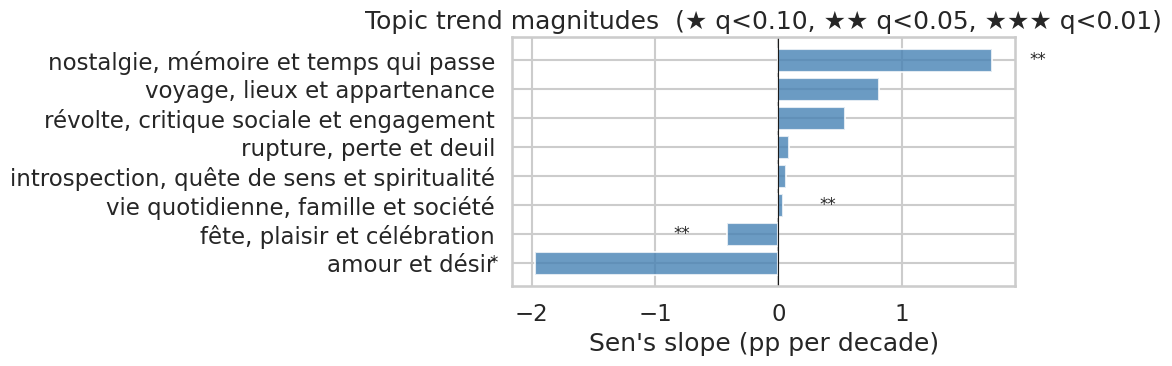

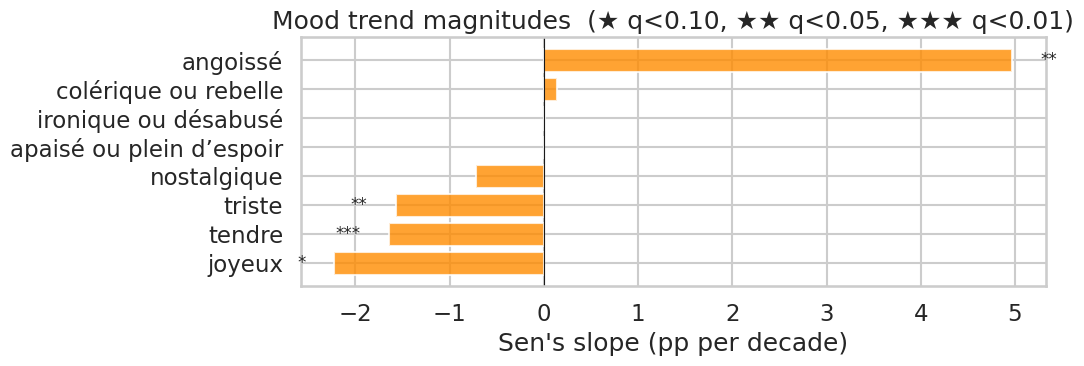

In [ ]:
def forest_plot_slopes(table, name, color):
    tbl = table.sort_values('sens_slope_pp_per_decade').reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(11, max(4, 0.4 * len(tbl))))
    y = np.arange(len(tbl))
    ax.barh(y, tbl['sens_slope_pp_per_decade'], color=color, alpha=0.8)
    for i, sig in enumerate(tbl['sig']):
        if sig:
            x = tbl['sens_slope_pp_per_decade'].iloc[i]
            ax.text(x + (0.3 if x >= 0 else -0.3), i, sig,
                    va='center', ha='left' if x >= 0 else 'right', fontsize=12)
    ax.set_yticks(y); ax.set_yticklabels(tbl['series_id'])
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_xlabel('Sen\'s slope (pp per decade)')
    ax.set_title(f'{name} trend magnitudes  (★ q<0.10, ★★ q<0.05, ★★★ q<0.01)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'sens_slope_{name.lower()}.png', dpi=200, bbox_inches='tight')
    plt.show()


forest_plot_slopes(mk_all[mk_all['series_type'] == 'topic'], 'Topic', 'steelblue')
forest_plot_slopes(mk_all[mk_all['series_type'] == 'mood'],  'Mood',  'darkorange')

Mann-Kendall tests with BH-FDR correction identified 8 significant trends out of 16 tested (4 topic, 4 mood). Filtering through the cross-model and genre-confound diagnostics produces three tiers.

**Robust trends** — survived cross-model validation (m2 confirms ≥ 0.42) and either strengthened or showed less than 25% attenuation with genre control:
- *Tendre* mood declined (−1.6 pp/decade, τ = −0.96, FDR < 0.001). The strongest single trend in the dataset by τ. French chanson became less affectively tender over the century.
- *Angoissé* mood rose (+5.0 pp/decade, τ = 0.75, FDR = 0.015). The largest absolute slope. Anxiety as a dominant mood grew substantially, especially from the 1980s onward.
- *Triste* mood declined (−1.6 pp/decade, τ = −0.67, FDR = 0.020). Sadness as a primary mood register shrank, though some of this may have migrated into angoissé or nostalgique.
- *Joyeux* mood declined (−2.2 pp/decade, τ = −0.53, FDR = 0.059). The weakest of the four (borderline after FDR), but directionally clear.
- *Nostalgie* topic rose (+1.7 pp/decade, τ = 0.71, FDR = 0.016). The most genre-robust topic trend — strengthened after controlling for genre composition.

**Partly confounded trends** — significant in Mann-Kendall but substantially attenuated (>50%) by genre adjustment:
- *Amour et désir topic declined* (−2.0 pp/decade, τ = −0.53, FDR = 0.059). Genuine but 70% attenuated by genre. Part of the decline reflects the displacement of pop-ballad love songs by rap and rock, not just an intra-genre change.
- *Fête, plaisir et célébration* declined (−0.4 pp/decade, τ = −0.64, FDR = 0.026). Genuine but 66% attenuated.

**Unreliable trends** — significant in Mann-Kendall but failed cross-model validation or genre control:
- *Vie quotidienne, famille et société* rose (+0.04 pp/decade, τ = 0.60, FDR = 0.028). The slope is tiny, the cross-model confirmation is 6%, and the genre regression produced a singular matrix. This trend should not be reported as a finding.

## 17) Exports

In [ ]:
# Song-level table (ensemble + final labels + multi-label tags)
keep = ['year','decade','song_title','artist_name', GENRE_COL, 'genre_top',
        'n_tokens_clean',
        'topic_label','topic_conf',
        'topic_ens_label','topic_ens_conf','topic_label_final','topic_multilabel',
        'mood_label','mood_conf',
        'mood_ens_label','mood_ens_conf','mood_label_final','mood_multilabel',
        'ensemble_coverage']
out = df[[c for c in keep if c in df.columns]].copy()
for c in ['topic_multilabel','mood_multilabel']:
    if c in out.columns:
        out[c] = out[c].apply(lambda lst: json.dumps(lst, ensure_ascii=False))
out.to_csv(OUTPUT_DIR / 'song_level_predictions_v5.csv', index=False)

# Aggregate shares
topic_counts_c.to_csv(OUTPUT_DIR / 'topic_share_by_decade_v5_capped.csv', index=False)
mood_counts_c.to_csv (OUTPUT_DIR / 'mood_share_by_decade_v5_capped.csv',  index=False)

print('v5 outputs:')
for p in sorted(OUTPUT_DIR.glob('*')):
    if p.is_file():
        print(f'  {p.stat().st_size:>10,d} B   {p.name}')

v5 outputs:
         383 B   crossmodel_label_mood.csv
         554 B   crossmodel_label_topic.csv
      95,324 B   crossmodel_spearman.png
         458 B   crossmodel_summary.csv
       1,165 B   genre_composition_by_decade.csv
      98,652 B   genre_composition_by_decade.png
         819 B   genre_confound_decomposition.csv
     134,741 B   gold_annotator_1.csv
     134,741 B   gold_annotator_2.csv
      28,341 B   gold_results_mood.csv
      32,290 B   gold_results_topic.csv
     127,352 B   gold_template_analyst_reference.csv
     117,524 B   gold_template_annotator_blank.csv
       3,001 B   mk_sens_slope_trends.csv
      10,811 B   mood_ci_cluster_capped.csv
     227,761 B   mood_heatmap_v5_capped.png
       3,428 B   mood_share_by_decade_v5_capped.csv
     209,488 B   mood_stacked_bar_v5_capped.png
      72,514 B   multilabel_distribution.png
      14,713 B   requirements_stage5.txt
     117,513 B   sens_slope_mood.png
     161,179 B   sens_slope_topic.png
  22,968,919 B   song_

## 18) Summary

This study classified 63,652 French-language songs (1925–2025) by topic and mood using zero-shot NLI, then stress-tested the results through five independent robustness checks:
- template sensitivity
- cross-model validation (mDeBERTa vs XLM-R-large)
- a single-annotator gold standard (n = 182)
- confidence calibration
- genre-adjusted logistic decomposition

The checks converged on a consistent picture:
- Out of 8 topic labels, 6 are cross-model reliable (m2 confirmation ≥ 35%); 2 are not (révolte at 16%, vie quotidienne at 6%)
- Out of 8 mood labels, 5 are reliable (m2 confirmation ≥ 42%); 3 are not (colérique ou rebelle at 1.5%, ironique ou désabusé at 1.6%, apaisé ou plein d'espoir at 5.6%)

Template sensitivity, gold-standard F1, and cross-model κ all flag the same labels as problematic, independently and without coordination.

Within the validated label set, five temporal trends survived FDR correction, cross-model validation, and genre adjustment.
- The dominant shift is emotional: French chanson became less tender (−1.6 pp/decade), less overtly sad (−1.6 pp/decade), and less joyful (−2.2 pp/decade), while anxiety as a primary mood register grew sharply (+5.0 pp/decade).
- On the thematic side, nostalgia rose steadily (+1.7 pp/decade) and actually strengthened after controlling for genre — making it the single most robust trend in the study.

Two additional topic trends (amour declining, fête declining) are statistically significant but 66–70% explained by genre composition changes (the displacement of pop ballads by rap and rock). They should be reported as partly confounded rather than as clean cultural shifts.

The most striking single finding from the genre-confound analysis is the reversal of révolte. Unadjusted, protest themes appeared to rise across the century. Adjusted for genre, the trend reverses. The "rise of protest in French popular music" — a common narrative — is, in this corpus, a genre-share artefact: rap grew, and rap is protest-coded. Within any single genre, révolte did not increase.

The classifier's limitations are real and measured. Topic κ against gold was 0.36; mood κ was 0.18 (rising to 0.52 on the five validated labels). Template sensitivity hovered around 35%. These numbers reflect the difficulty of applying zero-shot NLI to fine-grained French labels on poetic, ambiguous text — not a correctable implementation flaw. The trends that survive despite this noise are, precisely because of it, the ones worth discussing.